In [1]:
import os
# 1. GESTÃO DE MEMÓRIA (Deve ser executado antes de alocar memória no PyTorch)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import random
import time
import copy
import gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b7, EfficientNet_B7_Weights
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import autocast, GradScaler

from monai.transforms import (Compose, LoadImage, EnsureChannelFirst, Resize,
                              RandRotate, RandZoom, RandAdjustContrast, RandGaussianNoise,
                              NormalizeIntensity, Lambda, ToTensor)
from monai.losses import FocalLoss
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Forçar limpeza do lixo residual na placa gráfica
gc.collect()
torch.cuda.empty_cache()

# ========================================================
# 2. DETERMINISMO E PREPARAÇÃO DA GPU
# ========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo selecionado: {device}")

# ========================================================
# 3. CARREGAMENTO DOS CAMINHOS DAS IMAGENS
# ========================================================
base_dir = './dataset'
phases = ['train', 'val', 'test']
data = {phase: {'images': [], 'labels': []} for phase in phases}

class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
num_class = len(class_names)

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        image_files = [os.path.join(class_dir, x) for x in os.listdir(class_dir) if x.lower().endswith(valid_exts)]
        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)
    print(f"{phase.capitalize()} count = {len(data[phase]['images'])}")

# ========================================================
# 4. TRANSFORMAÇÕES (RESOLUÇÃO 256x256 PARA POUPAR VRAM)
# ========================================================
def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

train_transforms = Compose([
    LoadImage(image_only=True), EnsureChannelFirst(), Resize((256, 256)),
    RandRotate(range_x=15, prob=0.5), RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    RandAdjustContrast(prob=0.5), RandGaussianNoise(prob=0.3, mean=0.0, std=0.01),
    NormalizeIntensity(), Lambda(repeat_if_needed), ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True), EnsureChannelFirst(), Resize((256, 256)),
    NormalizeIntensity(), Lambda(repeat_if_needed), ToTensor()
])

class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms
    def __len__(self): return len(self.image_files)
    def __getitem__(self, index): return self.transforms(self.image_files[index]), self.labels[index]

# Batch Size de 1 para evitar OOM absoluto
BATCH_SIZE_EXTREMO = 1
train_ds = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_EXTREMO, shuffle=True, num_workers=0)

val_ds = MedNISTDataset(data['val']['images'], data['val']['labels'], val_transforms)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE_EXTREMO, num_workers=0)

test_ds = MedNISTDataset(data['test']['images'], data['test']['labels'], val_transforms)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE_EXTREMO, num_workers=0)

# ========================================================
# 5. INICIALIZAR A EFFICIENTNET-B7 E CONGELAR CAMADAS
# ========================================================
print("\nA inicializar a EfficientNet-B7 e a congelar 70% da rede...")
modelo_b7 = efficientnet_b7(weights=EfficientNet_B7_Weights.DEFAULT)

# O Segredo Anti-OOM: Congelar os primeiros 6 blocos para não calcular gradientes
for idx, child in enumerate(modelo_b7.features):
    if idx < 6: 
        for param in child.parameters():
            param.requires_grad = False

modelo_b7.classifier[1] = nn.Linear(modelo_b7.classifier[1].in_features, num_class)
modelo_b7 = modelo_b7.to(device)

# ========================================================
# 6. PARÂMETROS ORIGINAIS DA MÓNICA E TREINO COM AMP
# ========================================================
EPOCHS = 60
LEARNING_RATE = 1e-4
criterio = FocalLoss(to_onehot_y=True)

# Adam focado apenas nos parâmetros descongelados
otimizador = torch.optim.Adam(filter(lambda p: p.requires_grad, modelo_b7.parameters()), lr=LEARNING_RATE)
scheduler = CosineAnnealingLR(otimizador, T_max=EPOCHS)

def treinar_b7_amp(modelo, train_dl, val_dl, criterio, otimizador, scheduler, num_epocas=60):
    tempo_inicio = time.time()
    melhor_modelo_pesos = copy.deepcopy(modelo.state_dict())
    melhor_f1_val = -1.0 
    epocas_sem_melhoria = 0
    patience = 10 
    
    # 1 (Batch) x 16 (Passos) = 16 (Batch Size Virtual para manter a estabilidade)
    ACUMULACAO_PASSOS = 16 
    scaler = GradScaler()

    for epoca in range(num_epocas):
        print(f'\nÉpoca {epoca+1}/{num_epocas}')
        print('-' * 10)

        # -- TREINO --
        modelo.train()
        otimizador.zero_grad() 
        loss_acumulada_treino = 0.0
        todas_preds_treino, todas_labels_treino = [], []

        loop_treino = tqdm(train_dl, total=len(train_dl), leave=False, desc='Treino')
        for i, (imagens, labels) in enumerate(loop_treino):
            imagens, labels = imagens.to(device), labels.to(device)

            with autocast():
                saidas = modelo(imagens)
                loss = criterio(saidas, labels) / ACUMULACAO_PASSOS

            scaler.scale(loss).backward()

            if (i + 1) % ACUMULACAO_PASSOS == 0 or (i + 1) == len(train_dl):
                scaler.step(otimizador)
                scaler.update()
                otimizador.zero_grad()

            loss_acumulada_treino += loss.item() * ACUMULACAO_PASSOS * imagens.size(0)
            _, previsoes = torch.max(saidas, 1)
            todas_preds_treino.extend(previsoes.cpu().numpy())
            todas_labels_treino.extend(labels.cpu().numpy())

        epoca_loss_treino = loss_acumulada_treino / len(train_dl.dataset)
        f1_treino = f1_score(todas_labels_treino, todas_preds_treino, average='macro', zero_division=0)
        
        # -- VALIDAÇÃO --
        modelo.eval()
        todas_preds_val, todas_labels_val = [], []
        with torch.no_grad():
            for imagens, labels in val_dl:
                imagens, labels = imagens.to(device), labels.to(device)
                with autocast():
                    saidas = modelo(imagens)
                _, previsoes = torch.max(saidas, 1)
                todas_preds_val.extend(previsoes.cpu().numpy())
                todas_labels_val.extend(labels.cpu().numpy())

        f1_val = f1_score(todas_labels_val, todas_preds_val, average='macro', zero_division=0)

        print(f'Treino Loss: {epoca_loss_treino:.4f} | F1-Treino: {f1_treino:.4f}')
        print(f'Validação F1-Macro: {f1_val:.4f}')

        if f1_val > melhor_f1_val:
            melhor_f1_val = f1_val
            melhor_modelo_pesos = copy.deepcopy(modelo.state_dict())
            epocas_sem_melhoria = 0
            print(f"🌟 NOVO RECORDE VALIDAÇÃO (Modelo Guardado): {melhor_f1_val:.4f}")
        else:
            epocas_sem_melhoria += 1
                
        scheduler.step()
        if epocas_sem_melhoria >= patience:
            print(f"\n[Early Stopping] Estagnação detetada. Paragem na época {epoca+1}!")
            break

    tempo_decorrido = time.time() - tempo_inicio
    print(f'\nTreino completo em {tempo_decorrido // 60:.0f}m {tempo_decorrido % 60:.0f}s')
    modelo.load_state_dict(melhor_modelo_pesos)
    return modelo

# ========================================================
# 7. EXECUÇÃO DO TREINO E AVALIAÇÃO FINAL
# ========================================================
print("\n🔥 A iniciar o treino da B7 (AMP + Acumulação 16 + Features Congeladas)...")
modelo_final = treinar_b7_amp(modelo_b7, train_loader, val_loader, criterio, otimizador, scheduler, num_epocas=EPOCHS)

def evaluate_model_final(test_dl, modelo_treinado):
    predictions, actual_values = [], []
    modelo_treinado.eval()
    with torch.no_grad():
        for inputs, labels in test_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            with autocast():
                yprev = modelo_treinado(inputs)
            predictions.append(np.argmax(yprev.cpu().numpy(), axis=1).reshape(-1, 1))
            actual_values.append(labels.cpu().numpy().reshape(-1, 1))
            
    return np.vstack(actual_values), np.vstack(predictions)

print("\n" + "="*50 + "\nA INICIAR AVALIAÇÃO FINAL NO DATASET DE TESTE\n" + "="*50)
actual_values, predictions = evaluate_model_final(test_loader, modelo_final)

print("\nRELATÓRIO DE CLASSIFICAÇÃO B7 (DEFINITIVO):")
print(classification_report(actual_values, predictions, target_names=class_names, digits=4, zero_division=0))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(actual_values, predictions), annot=True, xticklabels=class_names, yticklabels=class_names, fmt='g', linewidths=.5)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Matriz de Confusão Final (EfficientNet-B7 Otimizada)')
plt.savefig("efficientnet_b7_final_cm.png", dpi=300)
plt.show()

Dispositivo selecionado: cuda:0
Train count = 1067
Val count = 234
Test count = 267

A inicializar a EfficientNet-B7 e a congelar 70% da rede...


/tmp/ipykernel_23849/372854258.py:142: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



🔥 A iniciar o treino da B7 (AMP + Acumulação 16 + Features Congeladas)...

Época 1/60
----------


Treino:   0%|          | 0/1067 [00:00<?, ?it/s]/tmp/ipykernel_23849/372854258.py:158: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_23849/372854258.py:183: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Treino Loss: 0.1379 | F1-Treino: 0.1864
Validação F1-Macro: 0.1047
🌟 NOVO RECORDE VALIDAÇÃO (Modelo Guardado): 0.1047

Época 2/60
----------


...

Treino Loss: 0.1163 | F1-Treino: 0.4237
Validação F1-Macro: 0.0465

Época 5/60
----------


Treino:   0%|          | 0/1067 [00:00<?, ?it/s]/tmp/ipykernel_23849/372854258.py:158: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_23849/372854258.py:183: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Treino Loss: 0.1034 | F1-Treino: 0.5716
Validação F1-Macro: 0.0525

Época 6/60
----------


Treino:   0%|          | 0/1067 [00:00<?, ?it/s]/tmp/ipykernel_23849/372854258.py:158: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
                                                          

KeyboardInterrupt: 

In [2]:
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot

%matplotlib inline
import matplotlib.pyplot as plt

from monai.transforms import (
    Activations, AsDiscrete, LoadImage, EnsureChannelFirst, Resize,
    RandZoom, RandAdjustContrast, RandGaussianNoise, RandRotate,
    RandFlip, RandAffine, RandGaussianSmooth,
    ToTensor, Compose, NormalizeIntensity, Lambda
)
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config

import numpy as np
import os
from PIL import Image
import random
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight
import time

import torch
from torch.utils.data import Dataset
from torchvision.models import efficientnet_b7
import torch.nn as nn
from torchmetrics.classification import MulticlassF1Score

np.random.seed(0)
set_determinism(seed=0)
print_config()


MONAI version: 1.5.2
Numpy version: 2.2.6
Pytorch version: 2.12.0+cu130
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /mounts/<username>/.local/lib/python3.10/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.15.3
Pillow version: 12.0.0
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.27.0+cu130
tqdm version: 4.67.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.0.0
pandas version: 2.3.3
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT IN

In [3]:
model_name = './models/efficientnet_b7_improved.pth'


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [5]:
base_dir = './dataset'
phases = ['train', 'val', 'test']

data = {phase: {'images': [], 'labels': []} for phase in phases}
class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
#class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
num_class = len(class_names)

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        image_files = [
                            os.path.join(class_dir, x)
                            for x in os.listdir(class_dir)
                            if x.lower().endswith(valid_exts)
                        ]

        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    print(f"{phase.capitalize()} count =", len(data[phase]['images']))
    

Train count = 1067
Val count = 234
Test count = 267


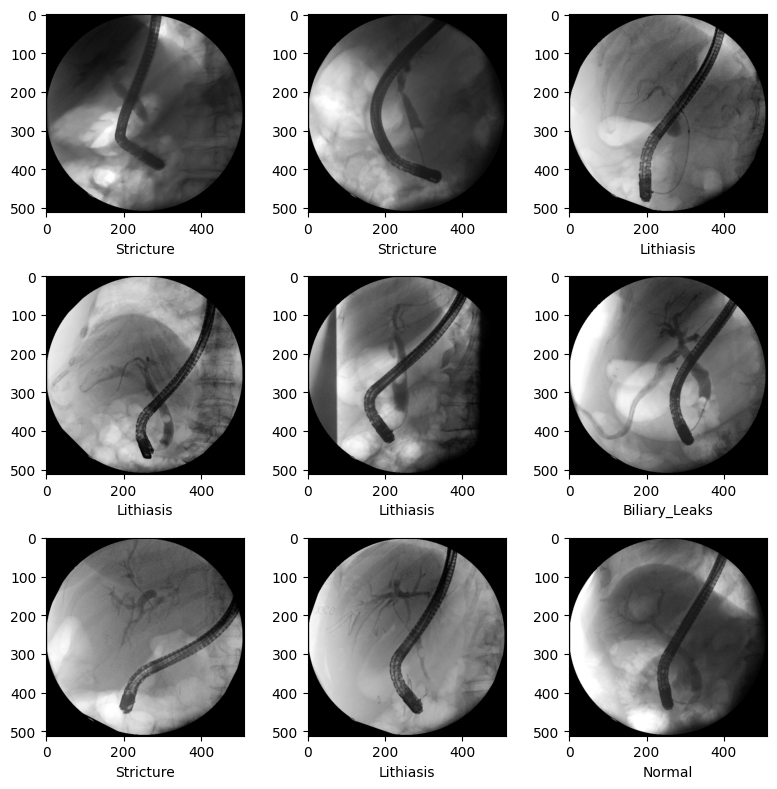

In [6]:
plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(len(data['train']['images']), size=9)):
    im = Image.open(data['train']['images'][k])
    arr = np.array(im)
    plt.subplot(3, 3, i + 1)
    plt.xlabel(class_names[data['train']['labels'][k]])
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
plt.tight_layout()
plt.show()


----- TRAIN CASES -----
cases: 1067
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[110 505 197 255]
1067


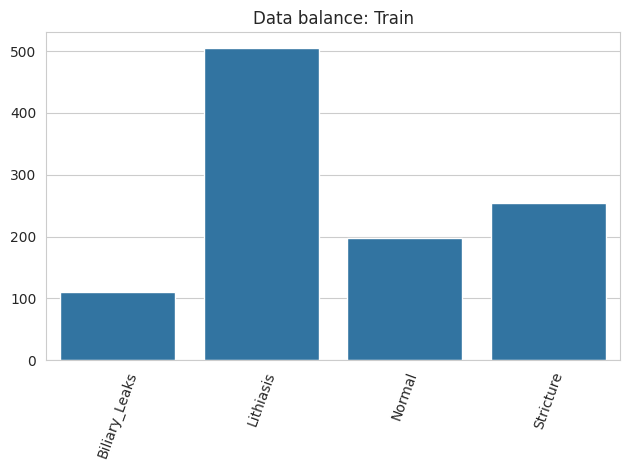

----- VALIDATION CASES -----
cases: 234
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[24 98 59 53]
234


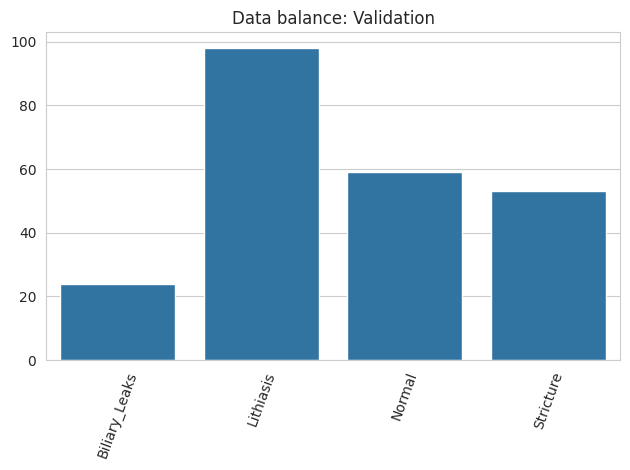

----- TEST CASES -----
cases: 267
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[ 17 123  43  84]
267


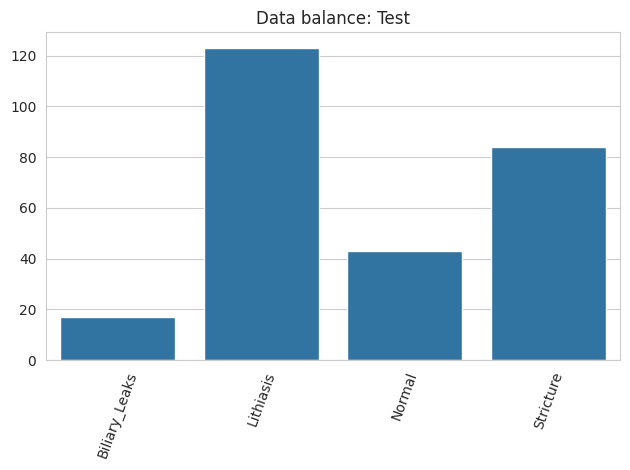

In [7]:
def visualize_holdout_balance(labels, class_names, header):
    sns.set_style('whitegrid')
    print("cases:", len(labels))
    x, y = np.unique(labels, return_counts=True)
    x_ext=[class_names[n]  for n in x]
    print(x_ext)
    print([str(n) for n in x])
    print(y)
    print(np.sum(y))
    grafico=sns.barplot(x=x_ext, y=y)
    grafico.set_title(f'Data balance: {header}')
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

print("----- TRAIN CASES -----")
visualize_holdout_balance(data['train']['labels'], class_names, 'Train')
print("----- VALIDATION CASES -----")
visualize_holdout_balance(data['val']['labels'], class_names, 'Validation')
print("----- TEST CASES -----")
visualize_holdout_balance(data['test']['labels'], class_names, 'Test')


In [8]:
train_labels_np = np.array(data['train']['labels'])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_class),
    y=train_labels_np
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print('Class weights:', class_weights_tensor)


Class weights: tensor([2.4250, 0.5282, 1.3541, 1.0461])


In [9]:
class EnsureSingleChannel:
    def __call__(self, img):
        if img.shape[0] == 3:
            img = img.mean(dim=0, keepdim=True)
        return img

def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    # Spatial
    RandFlip(spatial_axis=0, prob=0.5),
    RandFlip(spatial_axis=1, prob=0.5),
    RandAffine(
        prob=0.5,
        rotate_range=0.3,
        shear_range=0.1,
        translate_range=20,
        padding_mode='border'
    ),
    RandZoom(min_zoom=0.85, max_zoom=1.15, prob=0.5),
    # Intensity
    RandAdjustContrast(prob=0.5, gamma=(0.7, 1.5)),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.02),
    RandGaussianSmooth(prob=0.2),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

act = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)


In [10]:
class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image = self.image_files[index]
        return self.transforms(image), self.labels[index]

train_ds = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)

val_ds = MedNISTDataset(data['val']['images'], data['val']['labels'], val_transforms)
val_loader = DataLoader(val_ds, batch_size=4, num_workers=0)

test_ds = MedNISTDataset(data['test']['images'], data['test']['labels'], val_transforms)
test_loader = DataLoader(test_ds, batch_size=4, num_workers=0)

In [11]:
device = torch.device("cuda:0")
model = efficientnet_b7(pretrained=True) 
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_class) 
model = model.to(device)

/mounts/mecd-ap-g6/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mounts/mecd-ap-g6/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B7_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B7_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [12]:
def train_model(train_dl, val_dl, model, loss_function, optimizer, epochs, name,
                scheduler=None):
    early_stopping_patience = 10
    epochs_without_improvement = 0
    liveloss = PlotLosses(outputs=[MatplotlibPlot(figpath=f'{name}.png')])
    best_metric = -1
    best_metric_epoch = -1
    best_train_f1 = -1

    f1_metric  = MulticlassF1Score(num_classes=num_class, average='macro').to(device)
    auc_metric = ROCAUCMetric()

    for epoch in range(epochs):
        logs = {}
        model.train()
        running_loss = 0.0
        running_corrects = 0.0
        y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
        y_train      = torch.tensor([], dtype=torch.long,    device=device)

        for inputs, labels in train_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = loss_function(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
                scheduler.step()
            running_loss     += loss.detach() * inputs.size(0)
            _, preds          = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            y_pred_train      = torch.cat([y_pred_train, outputs], dim=0)
            y_train           = torch.cat([y_train, labels],        dim=0)

        epoch_loss = running_loss / len(train_dl.dataset)
        epoch_acc  = running_corrects.float() / len(train_dl.dataset)
        f1_train   = f1_metric(y_pred_train.argmax(dim=1), y_train)
        logs.update({'loss': epoch_loss.item(), 'accuracy': epoch_acc.item(),
                     'F1': f1_train.item()})

        model.eval()
        running_loss = 0.0
        running_corrects = 0.0
        y_pred = torch.tensor([], dtype=torch.float32, device=device)
        y      = torch.tensor([], dtype=torch.long,    device=device)

        with torch.no_grad():
            for val_images, val_labels in val_dl:
                val_images, val_labels = val_images.to(device), val_labels.to(device)
                outputs       = model(val_images)
                loss          = loss_function(outputs, val_labels)
                running_loss += loss.detach() * val_images.size(0)
                _, preds      = torch.max(outputs, 1)
                running_corrects += torch.sum(preds == val_labels.data)
                y_pred = torch.cat([y_pred, outputs], dim=0)
                y      = torch.cat([y, val_labels],   dim=0)

            epoch_loss = running_loss / len(val_dl.dataset)
            epoch_acc  = running_corrects.float() / len(val_dl.dataset)
            f1_val     = f1_metric(y_pred.argmax(dim=1), y)
            logs.update({'val_loss': epoch_loss.item(), 'val_accuracy': epoch_acc.item(),
                         'val_F1': f1_val.item()})

            y_onehot   = [to_onehot(i) for i in decollate_batch(y, detach=False)]
            y_pred_act = [act(i)       for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            logs['val_AUC'] = result

            if f1_val > best_metric:
                best_metric       = f1_val
                best_metric_epoch = epoch + 1
                best_train_f1     = f1_train.item()
                torch.save(model.state_dict(), name)
                print('saved new best metric model')
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= early_stopping_patience:
                print(f'Early stopping at epoch {epoch+1} | '
                      f'Best Val F1: {best_metric:.4f} @ epoch {best_metric_epoch}')
                break

            print(f'ep {epoch+1:3d} | AUC {result:.4f} | '
                  f'F1 tr {f1_train:.4f} | F1 val {f1_val:.4f} | '
                  f'best {best_metric:.4f} @ ep {best_metric_epoch}')

        liveloss.update(logs)
        liveloss.send()

        if scheduler is not None and not isinstance(
            scheduler, torch.optim.lr_scheduler.OneCycleLR
        ):
            scheduler.step()

    print(f'Training done — best F1: {best_metric:.4f} at epoch {best_metric_epoch}')


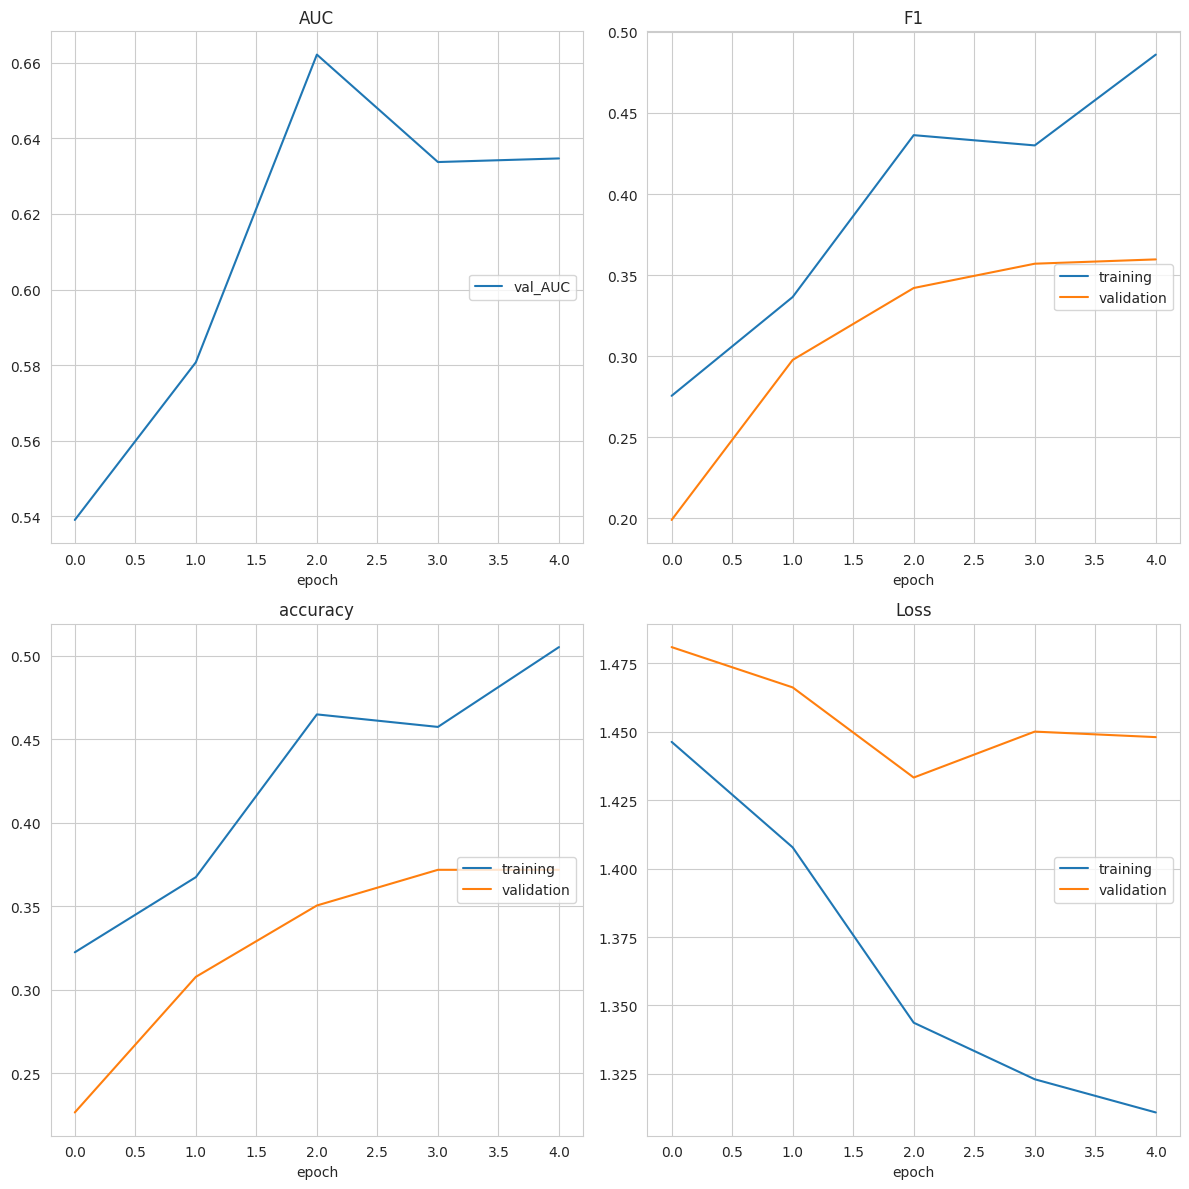

Training done — best F1: 0.3597 at epoch 5
Phase 1 time: 408s


In [13]:
EPOCHS_PHASE1 = 5
EPOCHS_PHASE2 = 55

device = torch.device('cuda:0')

# Loss: CrossEntropy + label smoothing + class weights
loss_function = nn.CrossEntropyLoss(
    weight=class_weights_tensor.to(device),
    label_smoothing=0.1
)

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

optimizer_p1 = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)
scheduler_p1 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_p1,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS_PHASE1
)

print('=== Phase 1: training classifier head only ===')
starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function,
            optimizer_p1, EPOCHS_PHASE1, model_name, scheduler=scheduler_p1)
print(f'Phase 1 time: {time.perf_counter() - starttime:.0f}s')


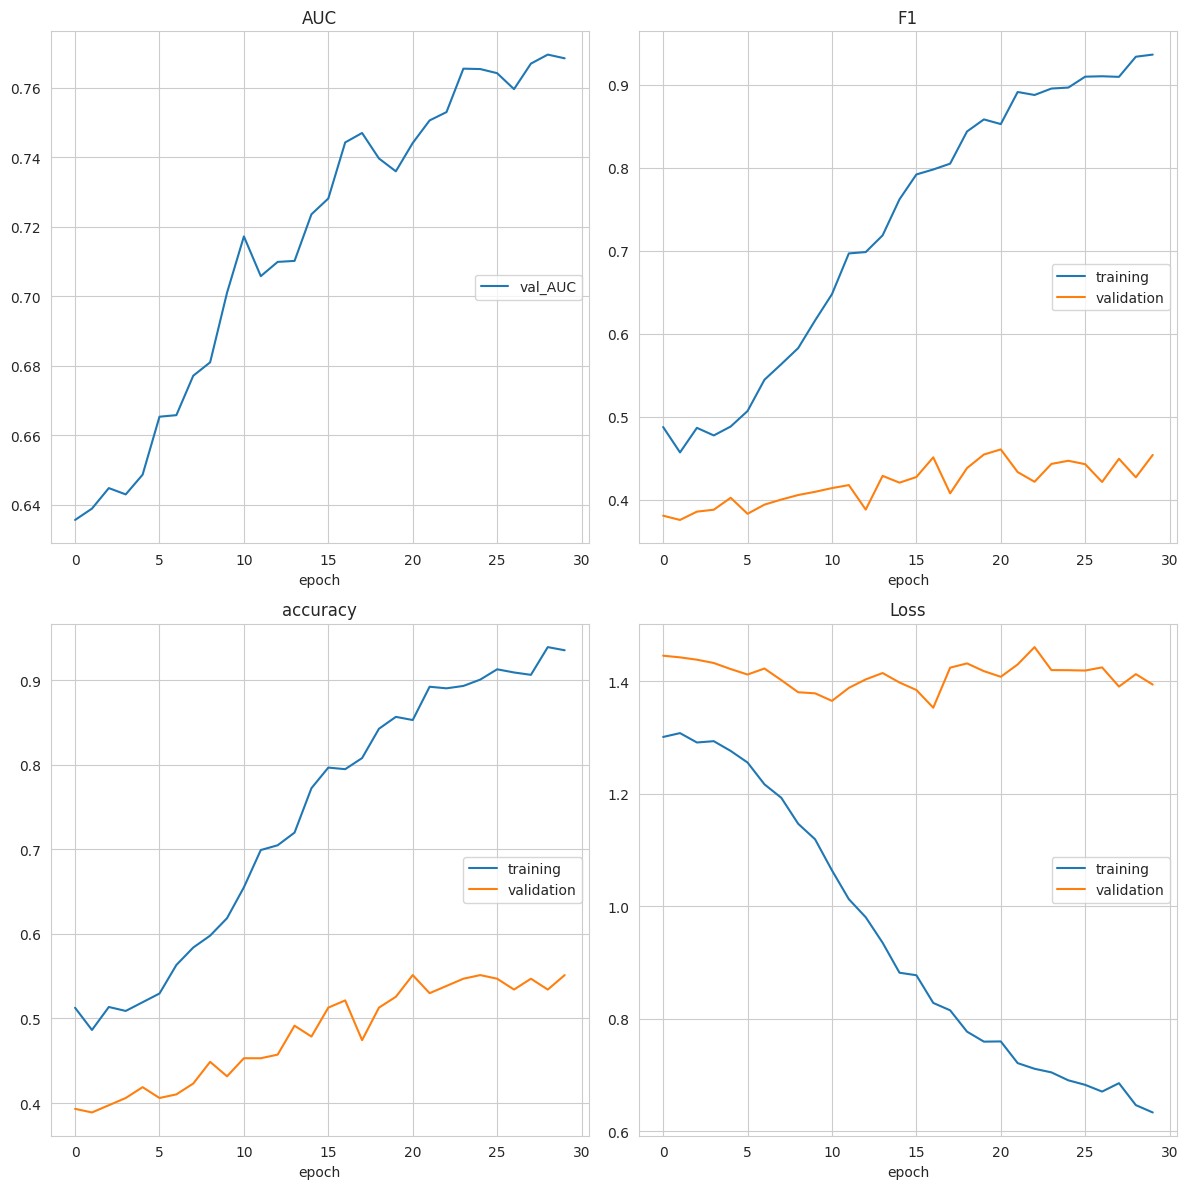

Early stopping at epoch 31 | Best Val F1: 0.4606 @ epoch 21
Training done — best F1: 0.4606 at epoch 21
Phase 2 time: 2878s


In [14]:
for param in model.features.parameters():
    param.requires_grad = True

optimizer_p2 = torch.optim.Adam([
    {'params': model.features.parameters(),    'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-4},
])

scheduler_p2 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_p2,
    max_lr=[1e-5, 1e-4],
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS_PHASE2
)

print('=== Phase 2: full fine-tuning with differential LRs ===')
starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function,
            optimizer_p2, EPOCHS_PHASE2, model_name, scheduler=scheduler_p2)
print(f'Phase 2 time: {time.perf_counter() - starttime:.0f}s')



--- Standard inference ---
F1 Score (no TTA): 0.4450
Accuracy : 0.5655  |  F1 macro: 0.4450
               precision    recall  f1-score   support

Biliary_Leaks     0.0769    0.0588    0.0667        17
    Lithiasis     0.6587    0.6748    0.6667       123
       Normal     0.3671    0.6744    0.4754        43
    Stricture     0.7755    0.4524    0.5714        84

     accuracy                         0.5655       267
    macro avg     0.4696    0.4651    0.4450       267
 weighted avg     0.6115    0.5655    0.5677       267


--- TTA x5 ---
F1 Score (TTA x5): 0.4971
Accuracy : 0.6292  |  F1 macro: 0.4971
               precision    recall  f1-score   support

Biliary_Leaks     0.0909    0.0588    0.0714        17
    Lithiasis     0.7087    0.7317    0.7200       123
       Normal     0.4400    0.7674    0.5593        43
    Stricture     0.8148    0.5238    0.6377        84

     accuracy                         0.6292       267
    macro avg     0.5136    0.5204    0.4971       

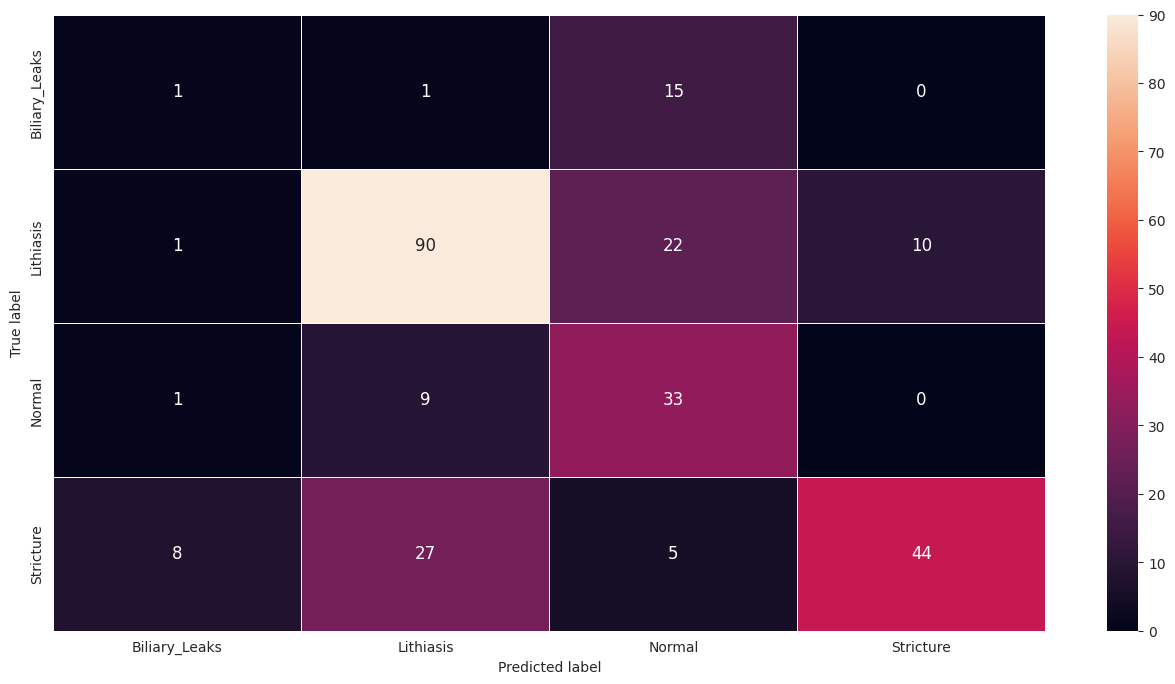

In [15]:
def evaluate_model(test_dl, model):
    """Standard inference — no augmentation."""
    model.eval()
    predictions, actual_values = [], []
    with torch.no_grad():
        for inputs, labels in test_dl:
            inputs = inputs.to(device)
            yprev  = model(inputs).cpu().numpy()
            actual = labels.numpy()
            predictions.append(np.argmax(yprev, axis=1).reshape(-1, 1))
            actual_values.append(actual.reshape(-1, 1))
    predictions   = np.vstack(predictions)
    actual_values = np.vstack(actual_values)
    f1 = f1_score(actual_values, predictions, average='macro')
    print(f'F1 Score (no TTA): {f1:.4f}')
    return actual_values, predictions


tta_aug = Compose([
    RandFlip(spatial_axis=0, prob=0.5),
    RandFlip(spatial_axis=1, prob=0.5),
    RandAffine(prob=0.5, rotate_range=0.2, translate_range=10, padding_mode='border'),
    RandAdjustContrast(prob=0.3, gamma=(0.8, 1.2)),
])

def evaluate_model_tta(test_dl, model, n_tta=5):
    """Inference with TTA: average softmax over n_tta augmented copies."""
    model.eval()
    predictions, actual_values = [], []
    with torch.no_grad():
        for inputs, labels in test_dl:
            inputs = inputs.to(device)
            probs  = torch.zeros(inputs.size(0), num_class, device=device)
            for _ in range(n_tta):
                aug = torch.stack([tta_aug(img.cpu()).to(device) for img in inputs])
                probs += torch.softmax(model(aug), dim=1)
            probs /= n_tta
            predictions.append(probs.argmax(dim=1).cpu().numpy().reshape(-1, 1))
            actual_values.append(labels.numpy().reshape(-1, 1))
    predictions   = np.vstack(predictions)
    actual_values = np.vstack(actual_values)
    f1 = f1_score(actual_values, predictions, average='macro')
    print(f'F1 Score (TTA x{n_tta}): {f1:.4f}')
    return actual_values, predictions


def display_results(actual_values, predictions):
    acc = accuracy_score(actual_values, predictions)
    f1  = f1_score(actual_values, predictions, average='macro')
    print(f'Accuracy : {acc:.4f}  |  F1 macro: {f1:.4f}')
    print(classification_report(actual_values, predictions,
                                 target_names=class_names, digits=4, zero_division=0))


def display_confusion_matrix(cm, list_classes, filename):
    plt.figure(figsize=(16, 8))
    sns.heatmap(cm, annot=True,
                xticklabels=list_classes, yticklabels=list_classes,
                annot_kws={'size': 12}, fmt='g', linewidths=.5)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig(f'{filename}_cm.png', dpi=300)
    plt.show()


# ── Load best checkpoint ──────────────────────────────────────────────────
model.load_state_dict(torch.load(model_name))
model.eval()

print('\n--- Standard inference ---')
av, pr = evaluate_model(test_loader, model)
display_results(av, pr)

print('\n--- TTA x5 ---')
av_tta, pr_tta = evaluate_model_tta(test_loader, model, n_tta=5)
display_results(av_tta, pr_tta)

cm = confusion_matrix(av_tta, pr_tta)
display_confusion_matrix(cm, class_names, model_name)


In [16]:
#Temos de fazer alterações,Biliary_Leaks é o calcanhar de Aquiles

#Apenas 17 amostras de teste (classe muito rara)
#F1 de 0.07 — o modelo essencialmente ignora esta classe
#Precision 0.09 → quando prevê, erra quase sempre

#Lithiasis e Stricture funcionam razoavelmente (F1 0.67 e 0.57), o que confirma que o backbone aprende algo — o problema é o desbalanceamento extremo.
#A TTA ajudou (+0.05 F1), o que valida essa parte. Mas não chega para compensar o colapso em Biliary_Leaks.

Sun May 24 09:20:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.03             Driver Version: 580.159.03     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 6000 Ada Gene...    Off |   00000000:41:00.0 Off |                  Off |
| 32%   57C    P8             30W /  300W |   48384MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [17]:
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot

%matplotlib inline
import matplotlib.pyplot as plt

from monai.transforms import (
    Activations, AsDiscrete, LoadImage, EnsureChannelFirst, Resize,
    RandZoom, RandAdjustContrast, RandGaussianNoise, RandRotate,
    RandFlip, RandAffine, RandGaussianSmooth,
    ToTensor, Compose, NormalizeIntensity, Lambda
)
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config

import numpy as np
import os
from PIL import Image
import random
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight
import time

import torch
from torch.utils.data import Dataset
from torchvision.models import efficientnet_b7
import torch.nn as nn
from torchmetrics.classification import MulticlassF1Score

np.random.seed(0)
set_determinism(seed=0)
print_config()


MONAI version: 1.5.2
Numpy version: 2.2.6
Pytorch version: 2.12.0+cu130
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /mounts/<username>/.local/lib/python3.10/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.15.3
Pillow version: 12.0.0
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.27.0+cu130
tqdm version: 4.67.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.0.0
pandas version: 2.3.3
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT IN

In [18]:
model_name = './models/efficientnet_b7_improved.pth'

In [19]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [21]:
base_dir = './dataset'
phases = ['train', 'val', 'test']

data = {phase: {'images': [], 'labels': []} for phase in phases}
class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
#class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
num_class = len(class_names)

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        image_files = [
                            os.path.join(class_dir, x)
                            for x in os.listdir(class_dir)
                            if x.lower().endswith(valid_exts)
                        ]

        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    print(f"{phase.capitalize()} count =", len(data[phase]['images']))
    

Train count = 1067
Val count = 234
Test count = 267


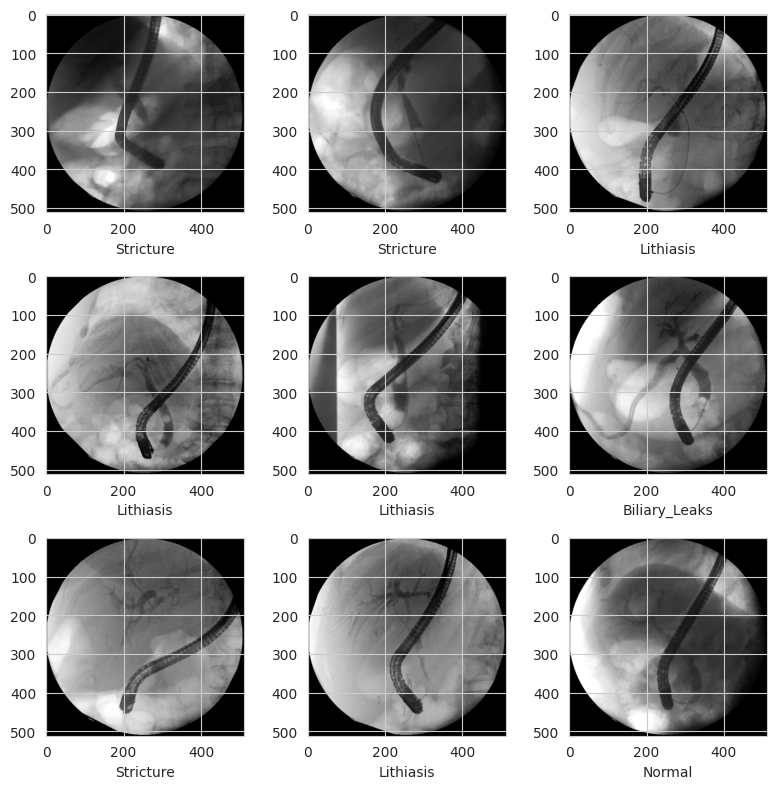

In [22]:
plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(len(data['train']['images']), size=9)):
    im = Image.open(data['train']['images'][k])
    arr = np.array(im)
    plt.subplot(3, 3, i + 1)
    plt.xlabel(class_names[data['train']['labels'][k]])
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
plt.tight_layout()
plt.show()


----- TRAIN CASES -----
cases: 1067
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[110 505 197 255]
1067


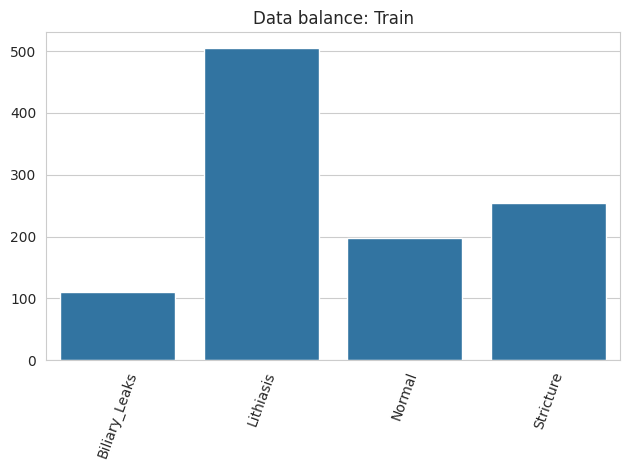

----- VALIDATION CASES -----
cases: 234
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[24 98 59 53]
234


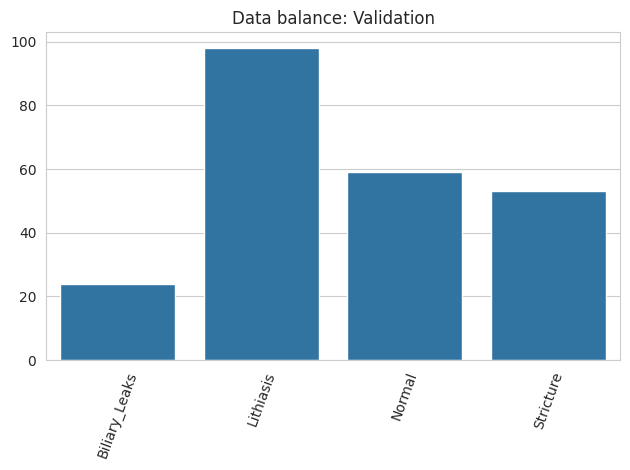

----- TEST CASES -----
cases: 267
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[ 17 123  43  84]
267


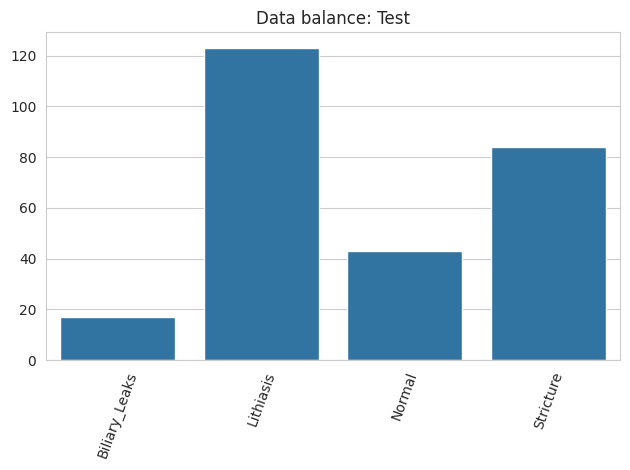

In [23]:
def visualize_holdout_balance(labels, class_names, header):
    sns.set_style('whitegrid')
    print("cases:", len(labels))
    x, y = np.unique(labels, return_counts=True)
    x_ext=[class_names[n]  for n in x]
    print(x_ext)
    print([str(n) for n in x])
    print(y)
    print(np.sum(y))
    grafico=sns.barplot(x=x_ext, y=y)
    grafico.set_title(f'Data balance: {header}')
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

print("----- TRAIN CASES -----")
visualize_holdout_balance(data['train']['labels'], class_names, 'Train')
print("----- VALIDATION CASES -----")
visualize_holdout_balance(data['val']['labels'], class_names, 'Validation')
print("----- TEST CASES -----")
visualize_holdout_balance(data['test']['labels'], class_names, 'Test')


In [24]:
train_labels_np = np.array(data['train']['labels'])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_class),
    y=train_labels_np
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print('Class weights:', class_weights_tensor)

# Per-sample weights for WeightedRandomSampler
sample_weights = [class_weights[label] for label in train_labels_np]
print(f'Sample weights — min: {min(sample_weights):.3f}  max: {max(sample_weights):.3f}')


Class weights: tensor([2.4250, 0.5282, 1.3541, 1.0461])
Sample weights — min: 0.528  max: 2.425


In [25]:
class EnsureSingleChannel:
    def __call__(self, img):
        if img.shape[0] == 3:
            img = img.mean(dim=0, keepdim=True)
        return img

def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    # Spatial
    RandFlip(spatial_axis=0, prob=0.5),
    RandFlip(spatial_axis=1, prob=0.5),
    RandAffine(
        prob=0.5,
        rotate_range=0.3,
        shear_range=0.1,
        translate_range=20,
        padding_mode='border'
    ),
    RandZoom(min_zoom=0.85, max_zoom=1.15, prob=0.5),
    # Intensity
    RandAdjustContrast(prob=0.5, gamma=(0.7, 1.5)),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.02),
    RandGaussianSmooth(prob=0.2),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

act = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)


In [26]:
from torch.utils.data import WeightedRandomSampler

class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels      = labels
        self.transforms  = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]


train_ds = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms)
val_ds   = MedNISTDataset(data['val']['images'],   data['val']['labels'],   val_transforms)
test_ds  = MedNISTDataset(data['test']['images'],  data['test']['labels'],  val_transforms)

# WeightedRandomSampler — gives minority classes equal expected frequency
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=4, sampler=sampler,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=4, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')


Train batches: 267 | Val batches: 59 | Test batches: 67


In [27]:
device = torch.device("cuda:0")
model = efficientnet_b7(pretrained=True) 
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_class) 
model = model.to(device)

/mounts/mecd-ap-g6/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mounts/mecd-ap-g6/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B7_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B7_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [28]:
def train_model(train_dl, val_dl, model, loss_function, optimizer, epochs, name,
                scheduler=None):
    early_stopping_patience = 10
    epochs_without_improvement = 0
    liveloss = PlotLosses(outputs=[MatplotlibPlot(figpath=f'{name}.png')])
    best_metric = -1
    best_metric_epoch = -1
    best_train_f1 = -1

    f1_metric  = MulticlassF1Score(num_classes=num_class, average='macro').to(device)
    auc_metric = ROCAUCMetric()

    for epoch in range(epochs):
        logs = {}
        model.train()
        running_loss = 0.0
        running_corrects = 0.0
        y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
        y_train      = torch.tensor([], dtype=torch.long,    device=device)

        for inputs, labels in train_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = loss_function(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
                scheduler.step()
            running_loss     += loss.detach() * inputs.size(0)
            _, preds          = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            y_pred_train      = torch.cat([y_pred_train, outputs], dim=0)
            y_train           = torch.cat([y_train, labels],        dim=0)

        epoch_loss = running_loss / len(train_dl.dataset)
        epoch_acc  = running_corrects.float() / len(train_dl.dataset)
        f1_train   = f1_metric(y_pred_train.argmax(dim=1), y_train)
        logs.update({'loss': epoch_loss.item(), 'accuracy': epoch_acc.item(),
                     'F1': f1_train.item()})

        model.eval()
        running_loss = 0.0
        running_corrects = 0.0
        y_pred = torch.tensor([], dtype=torch.float32, device=device)
        y      = torch.tensor([], dtype=torch.long,    device=device)

        with torch.no_grad():
            for val_images, val_labels in val_dl:
                val_images, val_labels = val_images.to(device), val_labels.to(device)
                outputs       = model(val_images)
                loss          = loss_function(outputs, val_labels)
                running_loss += loss.detach() * val_images.size(0)
                _, preds      = torch.max(outputs, 1)
                running_corrects += torch.sum(preds == val_labels.data)
                y_pred = torch.cat([y_pred, outputs], dim=0)
                y      = torch.cat([y, val_labels],   dim=0)

            epoch_loss = running_loss / len(val_dl.dataset)
            epoch_acc  = running_corrects.float() / len(val_dl.dataset)
            f1_val     = f1_metric(y_pred.argmax(dim=1), y)
            logs.update({'val_loss': epoch_loss.item(), 'val_accuracy': epoch_acc.item(),
                         'val_F1': f1_val.item()})

            y_onehot   = [to_onehot(i) for i in decollate_batch(y, detach=False)]
            y_pred_act = [act(i)       for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            logs['val_AUC'] = result

            if f1_val > best_metric:
                best_metric       = f1_val
                best_metric_epoch = epoch + 1
                best_train_f1     = f1_train.item()
                torch.save(model.state_dict(), name)
                print('saved new best metric model')
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= early_stopping_patience:
                print(f'Early stopping at epoch {epoch+1} | '
                      f'Best Val F1: {best_metric:.4f} @ epoch {best_metric_epoch}')
                break

            print(f'ep {epoch+1:3d} | AUC {result:.4f} | '
                  f'F1 tr {f1_train:.4f} | F1 val {f1_val:.4f} | '
                  f'best {best_metric:.4f} @ ep {best_metric_epoch}')

        liveloss.update(logs)
        liveloss.send()

        if scheduler is not None and not isinstance(
            scheduler, torch.optim.lr_scheduler.OneCycleLR
        ):
            scheduler.step()

    print(f'Training done — best F1: {best_metric:.4f} at epoch {best_metric_epoch}')


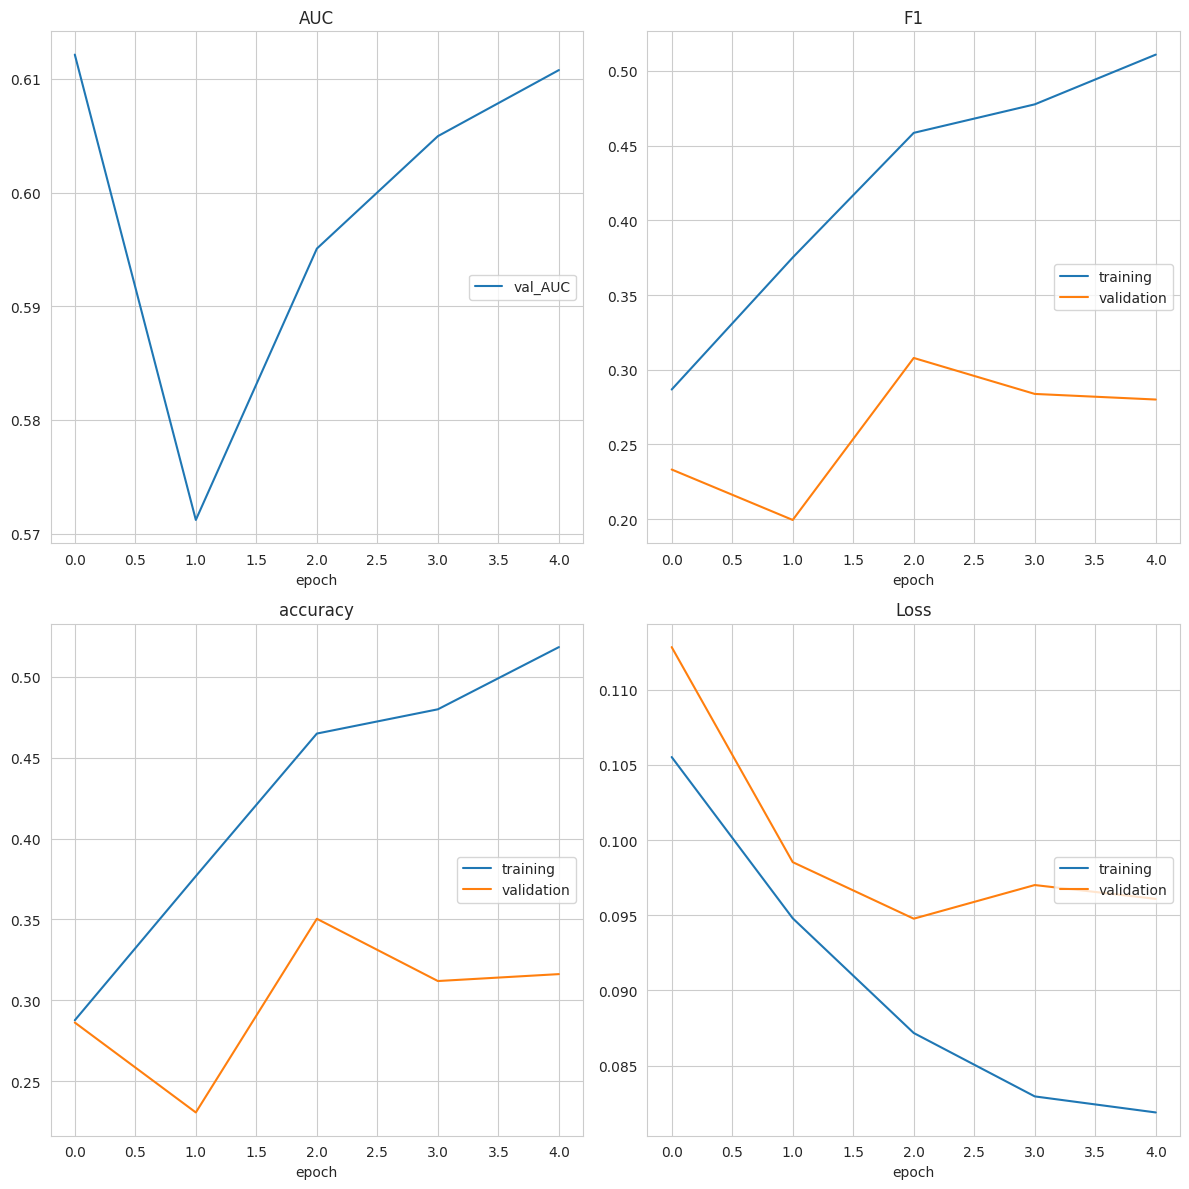

Training done — best F1: 0.3079 at epoch 3
Phase 1 time: 84s


In [31]:
EPOCHS_PHASE1 = 5
EPOCHS_PHASE2 = 55

device = torch.device('cuda:0')

# MONAI FocalLoss expects one-hot labels — wrap it to handle integer class indices
from monai.losses import FocalLoss as MonaiFocalLoss

class FocalLossWrapper(nn.Module):
    """Converts integer labels to one-hot before passing to MONAI FocalLoss."""
    def __init__(self, num_classes, gamma=3.0, weight=None):
        super().__init__()
        self.num_classes = num_classes
        self.focal = MonaiFocalLoss(gamma=gamma, weight=weight, reduction='mean')

    def forward(self, inputs, targets):
        # inputs : (B, C) logits
        # targets: (B,)  integer class indices
        targets_onehot = torch.zeros_like(inputs)  # (B, C)
        targets_onehot.scatter_(1, targets.unsqueeze(1), 1.0)
        return self.focal(inputs, targets_onehot)


loss_function = FocalLossWrapper(
    num_classes=num_class,
    gamma=3.0,
    weight=class_weights_tensor.to(device)
)

# Phase 1: freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

optimizer_p1 = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)
scheduler_p1 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_p1,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS_PHASE1
)

print('=== Phase 1: training classifier head only ===')
starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function,
            optimizer_p1, EPOCHS_PHASE1, model_name, scheduler=scheduler_p1)
print(f'Phase 1 time: {time.perf_counter() - starttime:.0f}s')


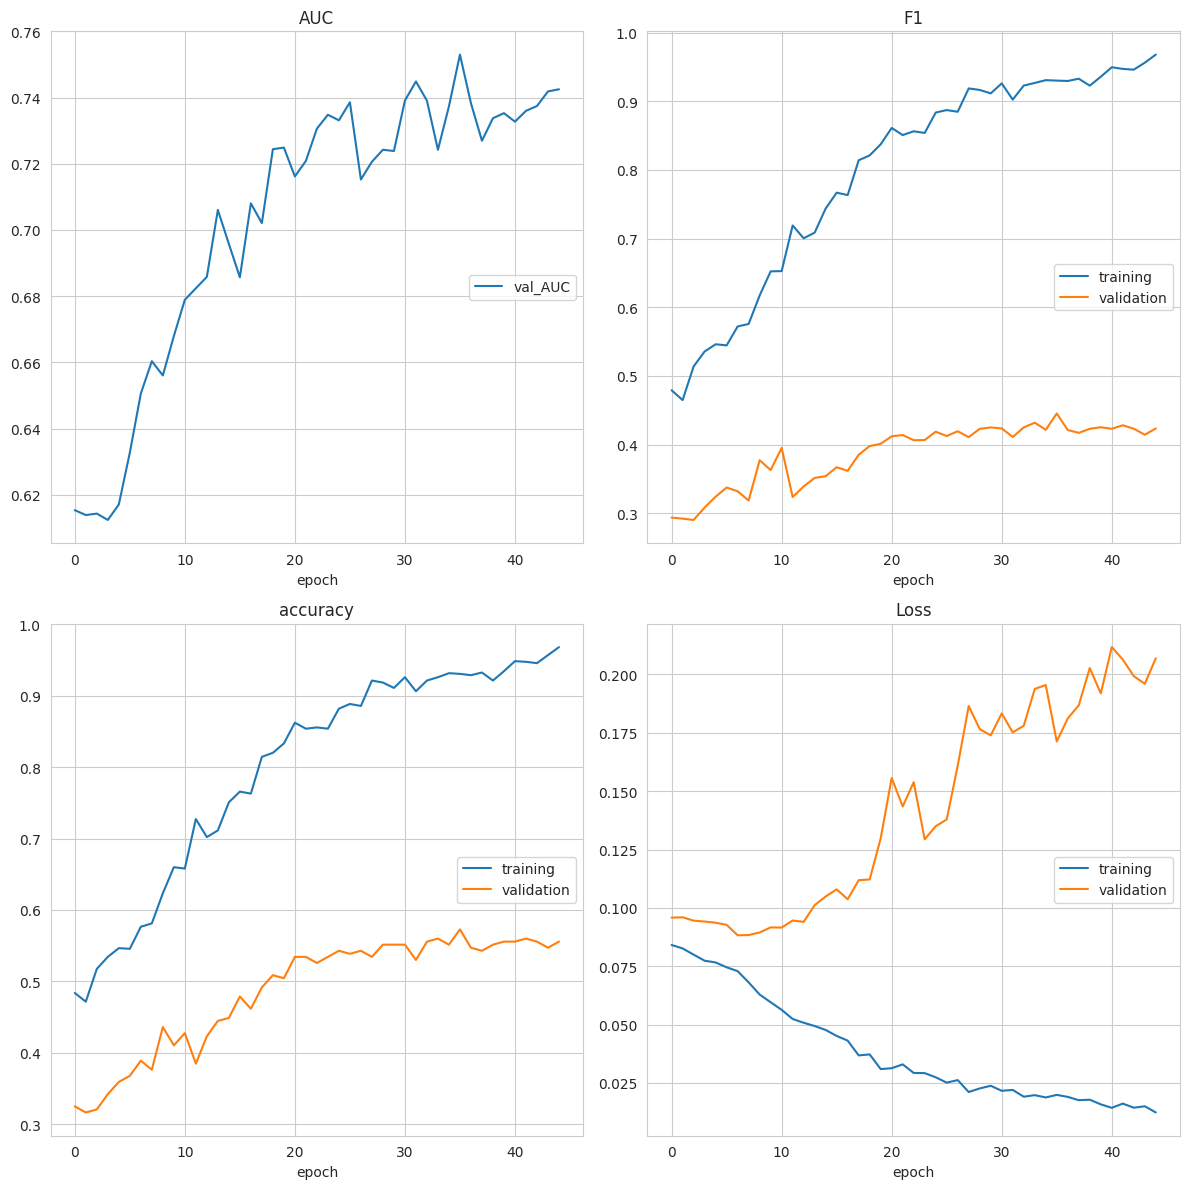

Early stopping at epoch 46 | Best Val F1: 0.4453 @ epoch 36
Training done — best F1: 0.4453 at epoch 36
Phase 2 time: 2091s


In [32]:
for param in model.features.parameters():
    param.requires_grad = True

optimizer_p2 = torch.optim.Adam([
    {'params': model.features.parameters(),    'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-4},
])

scheduler_p2 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_p2,
    max_lr=[1e-5, 1e-4],
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS_PHASE2
)

print('=== Phase 2: full fine-tuning with differential LRs ===')
starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function,
            optimizer_p2, EPOCHS_PHASE2, model_name, scheduler=scheduler_p2)
print(f'Phase 2 time: {time.perf_counter() - starttime:.0f}s')



--- Standard inference ---
F1 Score (no TTA): 0.4967
Accuracy : 0.5918  |  F1 macro: 0.4967
               precision    recall  f1-score   support

Biliary_Leaks     0.4000    0.1176    0.1818        17
    Lithiasis     0.6729    0.5854    0.6261       123
       Normal     0.4231    0.7674    0.5455        43
    Stricture     0.6623    0.6071    0.6335        84

     accuracy                         0.5918       267
    macro avg     0.5396    0.5194    0.4967       267
 weighted avg     0.6120    0.5918    0.5872       267


--- TTA x5 ---
F1 Score (TTA x5): 0.4988
Accuracy : 0.6292  |  F1 macro: 0.4988
               precision    recall  f1-score   support

Biliary_Leaks     0.5000    0.0588    0.1053        17
    Lithiasis     0.6772    0.6992    0.6880       123
       Normal     0.4110    0.6977    0.5172        43
    Stricture     0.7846    0.6071    0.6846        84

     accuracy                         0.6292       267
    macro avg     0.5932    0.5157    0.4988       

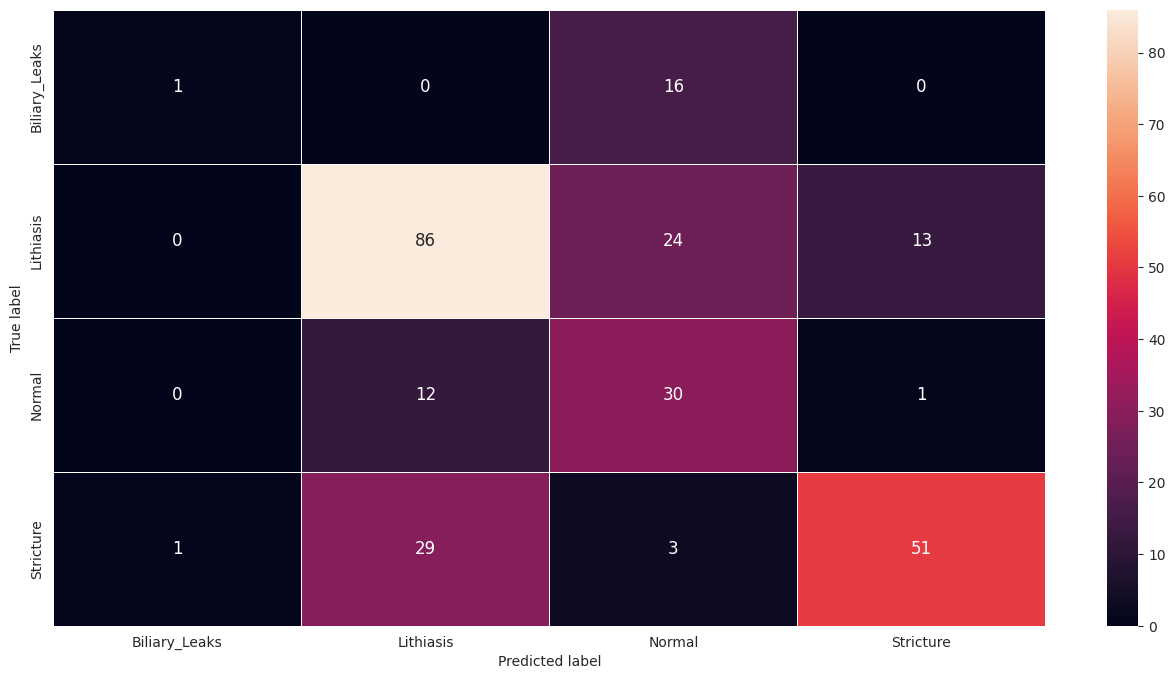

In [33]:
def evaluate_model(test_dl, model):
    """Standard inference — no augmentation."""
    model.eval()
    predictions, actual_values = [], []
    with torch.no_grad():
        for inputs, labels in test_dl:
            inputs = inputs.to(device)
            yprev  = model(inputs).cpu().numpy()
            actual = labels.numpy()
            predictions.append(np.argmax(yprev, axis=1).reshape(-1, 1))
            actual_values.append(actual.reshape(-1, 1))
    predictions   = np.vstack(predictions)
    actual_values = np.vstack(actual_values)
    f1 = f1_score(actual_values, predictions, average='macro')
    print(f'F1 Score (no TTA): {f1:.4f}')
    return actual_values, predictions


tta_aug = Compose([
    RandFlip(spatial_axis=0, prob=0.5),
    RandFlip(spatial_axis=1, prob=0.5),
    RandAffine(prob=0.5, rotate_range=0.2, translate_range=10, padding_mode='border'),
    RandAdjustContrast(prob=0.3, gamma=(0.8, 1.2)),
])

def evaluate_model_tta(test_dl, model, n_tta=5):
    """Inference with TTA: average softmax over n_tta augmented copies."""
    model.eval()
    predictions, actual_values = [], []
    with torch.no_grad():
        for inputs, labels in test_dl:
            inputs = inputs.to(device)
            probs  = torch.zeros(inputs.size(0), num_class, device=device)
            for _ in range(n_tta):
                aug = torch.stack([tta_aug(img.cpu()).to(device) for img in inputs])
                probs += torch.softmax(model(aug), dim=1)
            probs /= n_tta
            predictions.append(probs.argmax(dim=1).cpu().numpy().reshape(-1, 1))
            actual_values.append(labels.numpy().reshape(-1, 1))
    predictions   = np.vstack(predictions)
    actual_values = np.vstack(actual_values)
    f1 = f1_score(actual_values, predictions, average='macro')
    print(f'F1 Score (TTA x{n_tta}): {f1:.4f}')
    return actual_values, predictions


def display_results(actual_values, predictions):
    acc = accuracy_score(actual_values, predictions)
    f1  = f1_score(actual_values, predictions, average='macro')
    print(f'Accuracy : {acc:.4f}  |  F1 macro: {f1:.4f}')
    print(classification_report(actual_values, predictions,
                                 target_names=class_names, digits=4, zero_division=0))


def display_confusion_matrix(cm, list_classes, filename):
    plt.figure(figsize=(16, 8))
    sns.heatmap(cm, annot=True,
                xticklabels=list_classes, yticklabels=list_classes,
                annot_kws={'size': 12}, fmt='g', linewidths=.5)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig(f'{filename}_cm.png', dpi=300)
    plt.show()


# ── Load best checkpoint ──────────────────────────────────────────────────
model.load_state_dict(torch.load(model_name))
model.eval()

print('\n--- Standard inference ---')
av, pr = evaluate_model(test_loader, model)
display_results(av, pr)

print('\n--- TTA x5 ---')
av_tta, pr_tta = evaluate_model_tta(test_loader, model, n_tta=5)
display_results(av_tta, pr_tta)

cm = confusion_matrix(av_tta, pr_tta)
display_confusion_matrix(cm, class_names, model_name)


Getting validation probabilities...

Tuning thresholds on validation set:
  Class  0 (Biliary_Leaks       ): best threshold = 0.25  F1 = 0.0000
  Class  1 (Lithiasis           ): best threshold = 0.25  F1 = 0.0000
  Class  2 (Normal              ): best threshold = 0.25  F1 = 0.0000
  Class  3 (Stricture           ): best threshold = 0.25  F1 = 0.0000

Final thresholds: [0.25 0.25 0.25 0.25]

Getting test probabilities (with TTA x5)...

--- TTA x5 + argmax (no threshold tuning) ---
F1 macro: 0.5516
               precision    recall  f1-score   support

Biliary_Leaks     0.7500    0.1765    0.2857        17
    Lithiasis     0.6794    0.7236    0.7008       123
       Normal     0.4429    0.7209    0.5487        43
    Stricture     0.7903    0.5833    0.6712        84

     accuracy                         0.6442       267
    macro avg     0.6656    0.5511    0.5516       267
 weighted avg     0.6807    0.6442    0.6406       267


--- TTA x5 + threshold tuning ---
F1 macro: 0.4925
 

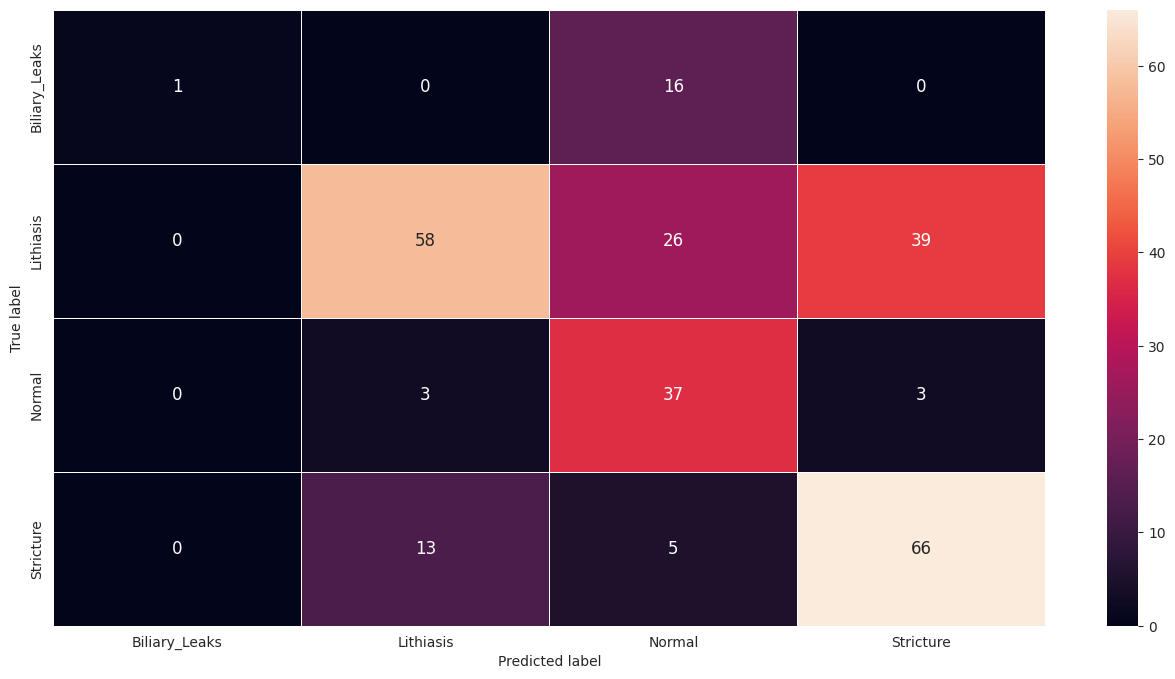

In [34]:
import numpy as np
from sklearn.metrics import f1_score

def get_probs(dl, model):
    """Return softmax probabilities and true labels for a dataloader."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in dl:
            inputs = inputs.to(device)
            probs  = torch.softmax(model(inputs), dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    return np.vstack(all_probs), np.concatenate(all_labels)


def tune_thresholds(val_probs, val_labels, num_classes, n_steps=50):
    """
    For each class independently, sweep the threshold on the validation set
    and pick the value that maximises that class's F1.
    Returns a threshold array of shape (num_classes,).
    """
    thresholds = np.full(num_classes, 1.0 / num_classes)  # default: uniform
    for c in range(num_classes):
        best_t, best_f1 = thresholds[c], 0.0
        for t in np.linspace(0.05, 0.95, n_steps):
            # predict class c whenever its prob > t, else argmax of the rest
            preds = np.where(val_probs[:, c] > t, c,
                             np.argmax(np.delete(val_probs, c, axis=1), axis=1))
            # shift indices back for classes after c
            preds = np.where(preds >= c, preds + (preds >= c), preds)
            f1 = f1_score(val_labels, preds, labels=[c], average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        thresholds[c] = best_t
        print(f'  Class {c:2d} ({class_names[c]:20s}): best threshold = {best_t:.2f}  F1 = {best_f1:.4f}')
    return thresholds


def predict_with_thresholds(probs, thresholds):
    """Apply per-class thresholds; highest-threshold-exceeding class wins, else argmax."""
    preds = np.argmax(probs, axis=1)  # fallback
    for c, t in enumerate(thresholds):
        preds = np.where(probs[:, c] > t, c, preds)
    return preds


# ── Load best checkpoint ──────────────────────────────────────────────────
model.load_state_dict(torch.load(model_name))
model.eval()

print('Getting validation probabilities...')
val_probs, val_labels_arr = get_probs(val_loader, model)

print('\nTuning thresholds on validation set:')
thresholds = tune_thresholds(val_probs, val_labels_arr, num_class)
print('\nFinal thresholds:', thresholds)

# ── Evaluate on test set ──────────────────────────────────────────────────
print('\nGetting test probabilities (with TTA x5)...')

def get_tta_probs(dl, model, n_tta=5):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in dl:
            inputs = inputs.to(device)
            probs  = torch.zeros(inputs.size(0), num_class, device=device)
            for _ in range(n_tta):
                aug = torch.stack([tta_aug(img.cpu()).to(device) for img in inputs])
                probs += torch.softmax(model(aug), dim=1)
            probs /= n_tta
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.vstack(all_probs), np.concatenate(all_labels)

test_probs, test_labels_arr = get_tta_probs(test_loader, model, n_tta=5)

print('\n--- TTA x5 + argmax (no threshold tuning) ---')
preds_base = np.argmax(test_probs, axis=1)
print(f'F1 macro: {f1_score(test_labels_arr, preds_base, average="macro"):.4f}')
print(classification_report(test_labels_arr, preds_base,
                             target_names=class_names, digits=4, zero_division=0))

print('\n--- TTA x5 + threshold tuning ---')
preds_tuned = predict_with_thresholds(test_probs, thresholds)
print(f'F1 macro: {f1_score(test_labels_arr, preds_tuned, average="macro"):.4f}')
print(classification_report(test_labels_arr, preds_tuned,
                             target_names=class_names, digits=4, zero_division=0))

cm = confusion_matrix(test_labels_arr, preds_tuned)
display_confusion_matrix(cm, class_names, model_name)


In [35]:
#E se aplicarmos o CLAHE??
# EfficientNet training — Improved Baseline v3
#Improvements over baseline (target: F1 macro > 0.73):
# **CLAHE** pre-processing — adaptive contrast enhancement for endoscopic images
#- **WeightedRandomSampler** — oversamples minority class (Biliary_Leaks)
#- **FocalLoss(gamma=3)** + class weights
#- **2-phase training** with differential learning rates
#- **Richer augmentation** (flips, affine, gaussian smooth)
#- **OneCycleLR** scheduler
#- **Test-Time Augmentation (TTA x5)** at inference
#- **Threshold tuning** per class on the validation set

In [36]:
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot

%matplotlib inline
import matplotlib.pyplot as plt

from monai.transforms import (
    Activations, AsDiscrete, LoadImage, EnsureChannelFirst, Resize,
    RandZoom, RandAdjustContrast, RandGaussianNoise, RandRotate,
    RandFlip, RandAffine, RandGaussianSmooth,
    ToTensor, Compose, NormalizeIntensity, Lambda
)
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config

import numpy as np
import os
from PIL import Image
import random
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight
import time

import torch
from torch.utils.data import Dataset
from torchvision.models import efficientnet_b7
import torch.nn as nn
from torchmetrics.classification import MulticlassF1Score

np.random.seed(0)
set_determinism(seed=0)
print_config()


MONAI version: 1.5.2
Numpy version: 2.2.6
Pytorch version: 2.12.0+cu130
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /mounts/<username>/.local/lib/python3.10/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.15.3
Pillow version: 12.0.0
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.27.0+cu130
tqdm version: 4.67.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.0.0
pandas version: 2.3.3
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT IN

In [37]:
model_name = './models/efficientnet_b7_improved.pth'


In [38]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [39]:
base_dir = './dataset'
phases = ['train', 'val', 'test']

data = {phase: {'images': [], 'labels': []} for phase in phases}
class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
#class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
num_class = len(class_names)

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        image_files = [
                            os.path.join(class_dir, x)
                            for x in os.listdir(class_dir)
                            if x.lower().endswith(valid_exts)
                        ]

        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    print(f"{phase.capitalize()} count =", len(data[phase]['images']))
    

Train count = 1067
Val count = 234
Test count = 267


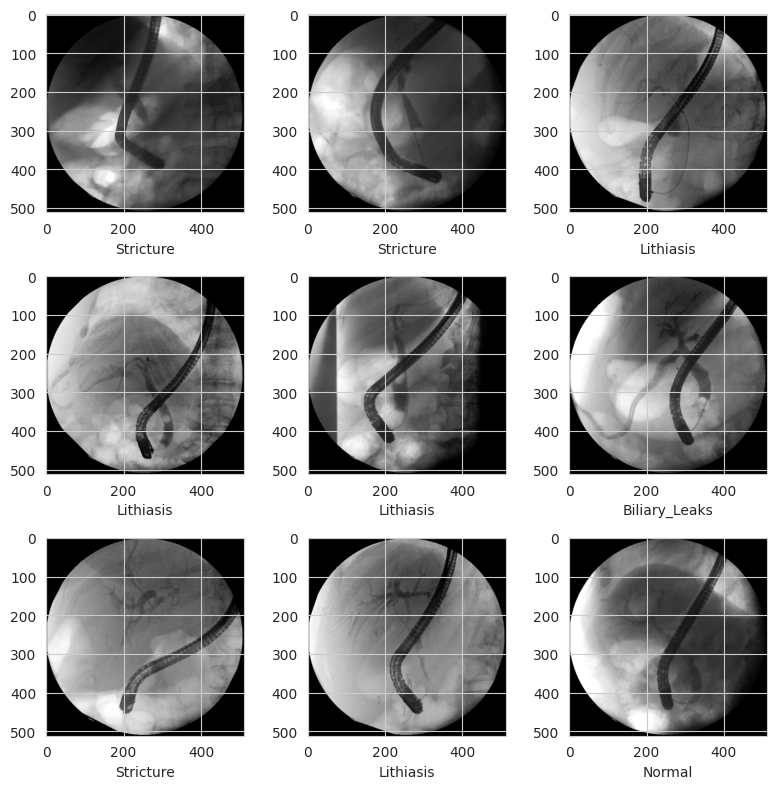

In [40]:
plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(len(data['train']['images']), size=9)):
    im = Image.open(data['train']['images'][k])
    arr = np.array(im)
    plt.subplot(3, 3, i + 1)
    plt.xlabel(class_names[data['train']['labels'][k]])
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
plt.tight_layout()
plt.show()


----- TRAIN CASES -----
cases: 1067
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[110 505 197 255]
1067


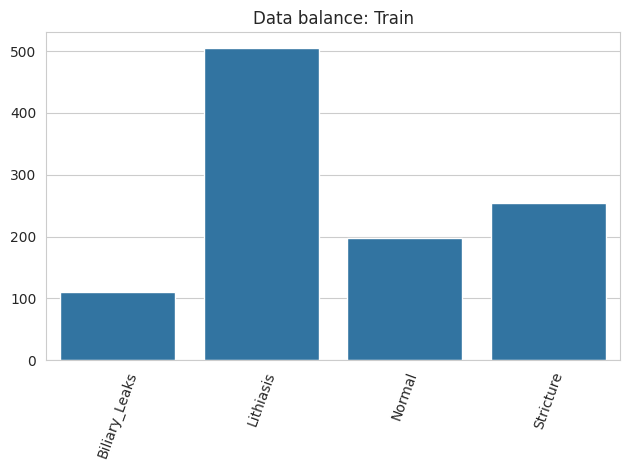

----- VALIDATION CASES -----
cases: 234
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[24 98 59 53]
234


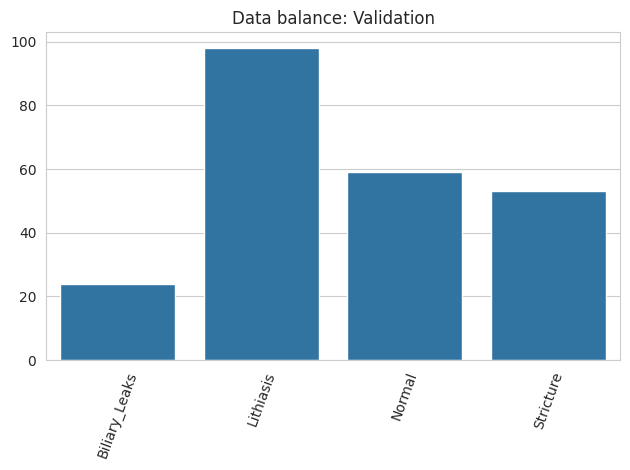

----- TEST CASES -----
cases: 267
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[ 17 123  43  84]
267


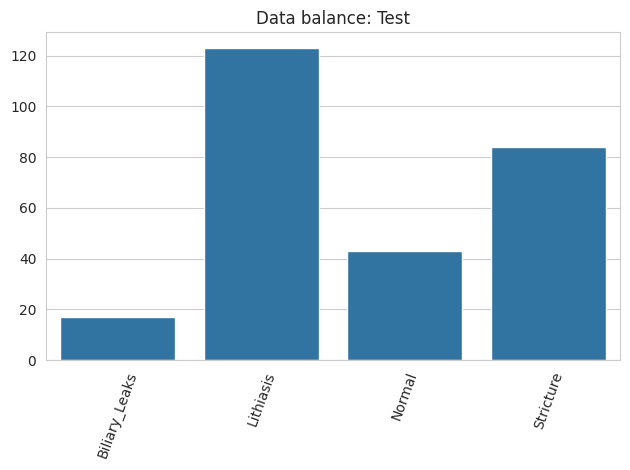

In [41]:
def visualize_holdout_balance(labels, class_names, header):
    sns.set_style('whitegrid')
    print("cases:", len(labels))
    x, y = np.unique(labels, return_counts=True)
    x_ext=[class_names[n]  for n in x]
    print(x_ext)
    print([str(n) for n in x])
    print(y)
    print(np.sum(y))
    grafico=sns.barplot(x=x_ext, y=y)
    grafico.set_title(f'Data balance: {header}')
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

print("----- TRAIN CASES -----")
visualize_holdout_balance(data['train']['labels'], class_names, 'Train')
print("----- VALIDATION CASES -----")
visualize_holdout_balance(data['val']['labels'], class_names, 'Validation')
print("----- TEST CASES -----")
visualize_holdout_balance(data['test']['labels'], class_names, 'Test')


In [42]:
import cv2

def apply_clahe(img_tensor, clip_limit=2.0, tile_grid=(8, 8)):
    """
    Apply CLAHE per channel on a (C, H, W) float32 tensor in [0, 1].
    Returns a tensor of the same shape and dtype.
    """
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    # to uint8 numpy
    img_np = (img_tensor.numpy().transpose(1, 2, 0) * 255).clip(0, 255).astype('uint8')
    if img_np.shape[2] == 1:
        enhanced = clahe.apply(img_np[:, :, 0])[:, :, np.newaxis]
    else:
        # Apply CLAHE on L channel of LAB for colour images (avoids colour shift)
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return torch.tensor(
        enhanced.transpose(2, 0, 1).astype('float32') / 255.0
    )


class CLAHETransform:
    """MONAI-compatible callable that wraps apply_clahe."""
    def __init__(self, clip_limit=2.0, tile_grid=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid  = tile_grid

    def __call__(self, img):
        return apply_clahe(img, self.clip_limit, self.tile_grid)


print('CLAHE transform defined.')


CLAHE transform defined.


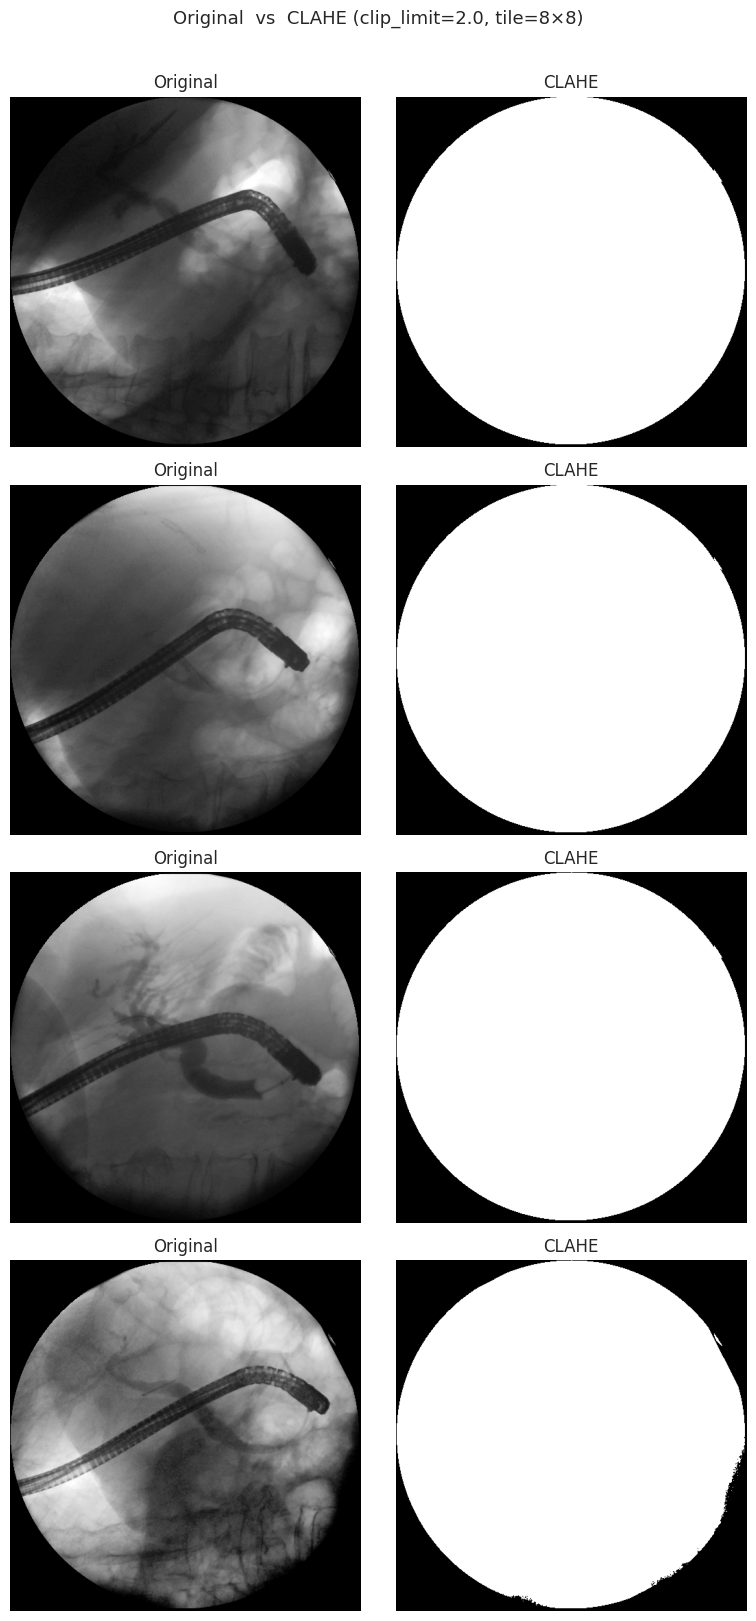

Saved clahe_preview.png


In [43]:
# ── Side-by-side visualisation: original vs CLAHE ────────────────────────
from monai.transforms import LoadImage, EnsureChannelFirst, Resize, ToTensor, Compose

_preview_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    ToTensor()
])

n_samples = 4
sample_paths = [
    data[phase]['images'][i]
    for phase in ['train']
    for i in np.random.choice(len(data[phase]['images']), n_samples, replace=False)
]

fig, axes = plt.subplots(n_samples, 2, figsize=(8, 4 * n_samples))
fig.suptitle('Original  vs  CLAHE (clip_limit=2.0, tile=8×8)', fontsize=13, y=1.01)

for row, path in enumerate(sample_paths):
    img = _preview_transforms(path)          # (C, H, W) float32
    img_clahe = apply_clahe(img)

    def to_show(t):
        t = t.numpy().transpose(1, 2, 0)
        t = (t - t.min()) / (t.max() - t.min() + 1e-8)
        return t if t.shape[2] == 3 else t[:, :, 0]

    axes[row, 0].imshow(to_show(img),       cmap='gray')
    axes[row, 0].set_title('Original')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(to_show(img_clahe), cmap='gray')
    axes[row, 1].set_title('CLAHE')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.savefig('clahe_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved clahe_preview.png')


In [44]:
#Saturou completamente, temos de reduzir

In [45]:
model_name = './models/efficientnet_b7_improved.pth'

In [46]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [47]:
base_dir = './dataset'
phases = ['train', 'val', 'test']

data = {phase: {'images': [], 'labels': []} for phase in phases}
class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
#class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
num_class = len(class_names)

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        image_files = [
                            os.path.join(class_dir, x)
                            for x in os.listdir(class_dir)
                            if x.lower().endswith(valid_exts)
                        ]

        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    print(f"{phase.capitalize()} count =", len(data[phase]['images']))
    

Train count = 1067
Val count = 234
Test count = 267


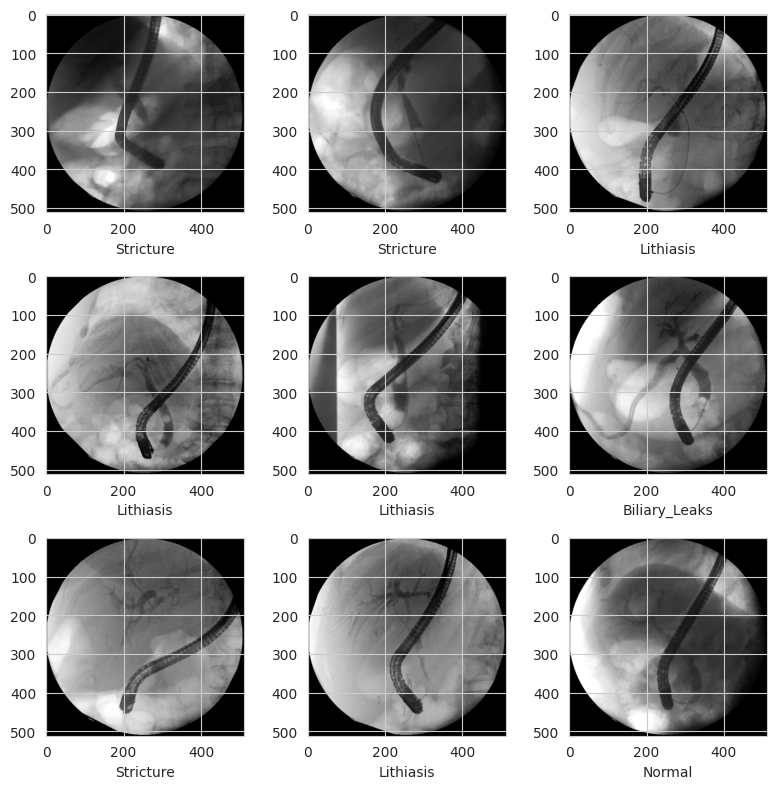

In [48]:
plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(len(data['train']['images']), size=9)):
    im = Image.open(data['train']['images'][k])
    arr = np.array(im)
    plt.subplot(3, 3, i + 1)
    plt.xlabel(class_names[data['train']['labels'][k]])
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
plt.tight_layout()
plt.show()


----- TRAIN CASES -----
cases: 1067
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[110 505 197 255]
1067


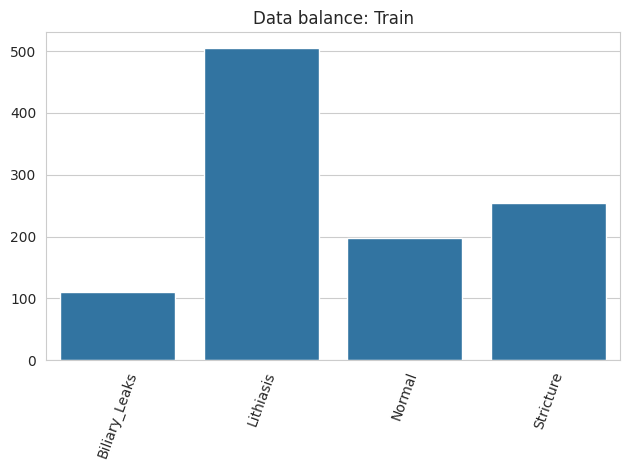

----- VALIDATION CASES -----
cases: 234
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[24 98 59 53]
234


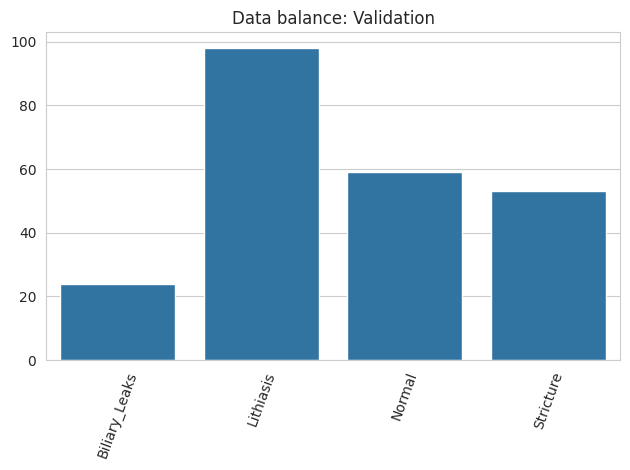

----- TEST CASES -----
cases: 267
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[ 17 123  43  84]
267


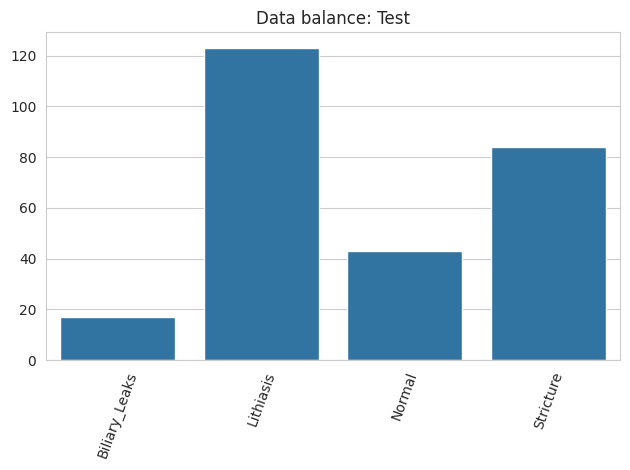

In [49]:
def visualize_holdout_balance(labels, class_names, header):
    sns.set_style('whitegrid')
    print("cases:", len(labels))
    x, y = np.unique(labels, return_counts=True)
    x_ext=[class_names[n]  for n in x]
    print(x_ext)
    print([str(n) for n in x])
    print(y)
    print(np.sum(y))
    grafico=sns.barplot(x=x_ext, y=y)
    grafico.set_title(f'Data balance: {header}')
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

print("----- TRAIN CASES -----")
visualize_holdout_balance(data['train']['labels'], class_names, 'Train')
print("----- VALIDATION CASES -----")
visualize_holdout_balance(data['val']['labels'], class_names, 'Validation')
print("----- TEST CASES -----")
visualize_holdout_balance(data['test']['labels'], class_names, 'Test')


In [50]:
import cv2

def apply_clahe(img_tensor, clip_limit=1.5, tile_grid=(8, 8)):
    """
    Apply CLAHE per channel on a (C, H, W) float32 tensor.
    Safely handles values outside [0, 1] by min-max normalising
    to uint8 before processing, then restoring to float32 [0, 1].
    Uses LAB colour space for RGB images to avoid colour shifts.
    """
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)

    img_np = img_tensor.numpy().transpose(1, 2, 0)  # (H, W, C)

    # ── Safe normalisation to [0, 255] uint8 ─────────────────────────
    vmin, vmax = img_np.min(), img_np.max()
    if vmax - vmin < 1e-8:          # blank / constant image — skip
        return img_tensor
    img_np = ((img_np - vmin) / (vmax - vmin) * 255).clip(0, 255).astype('uint8')

    # ── Apply CLAHE ───────────────────────────────────────────────────
    if img_np.shape[2] == 1:
        enhanced = clahe.apply(img_np[:, :, 0])[:, :, np.newaxis]
    else:
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # ── Back to float32 [0, 1] ────────────────────────────────────────
    out = enhanced.astype('float32') / 255.0
    return torch.tensor(out.transpose(2, 0, 1))   # (C, H, W)


class CLAHETransform:
    """MONAI-compatible callable that wraps apply_clahe."""
    def __init__(self, clip_limit=1.5, tile_grid=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid  = tile_grid

    def __call__(self, img):
        return apply_clahe(img, self.clip_limit, self.tile_grid)


print('CLAHE transform defined (clip_limit=1.5, safe normalisation).')


CLAHE transform defined (clip_limit=1.5, safe normalisation).


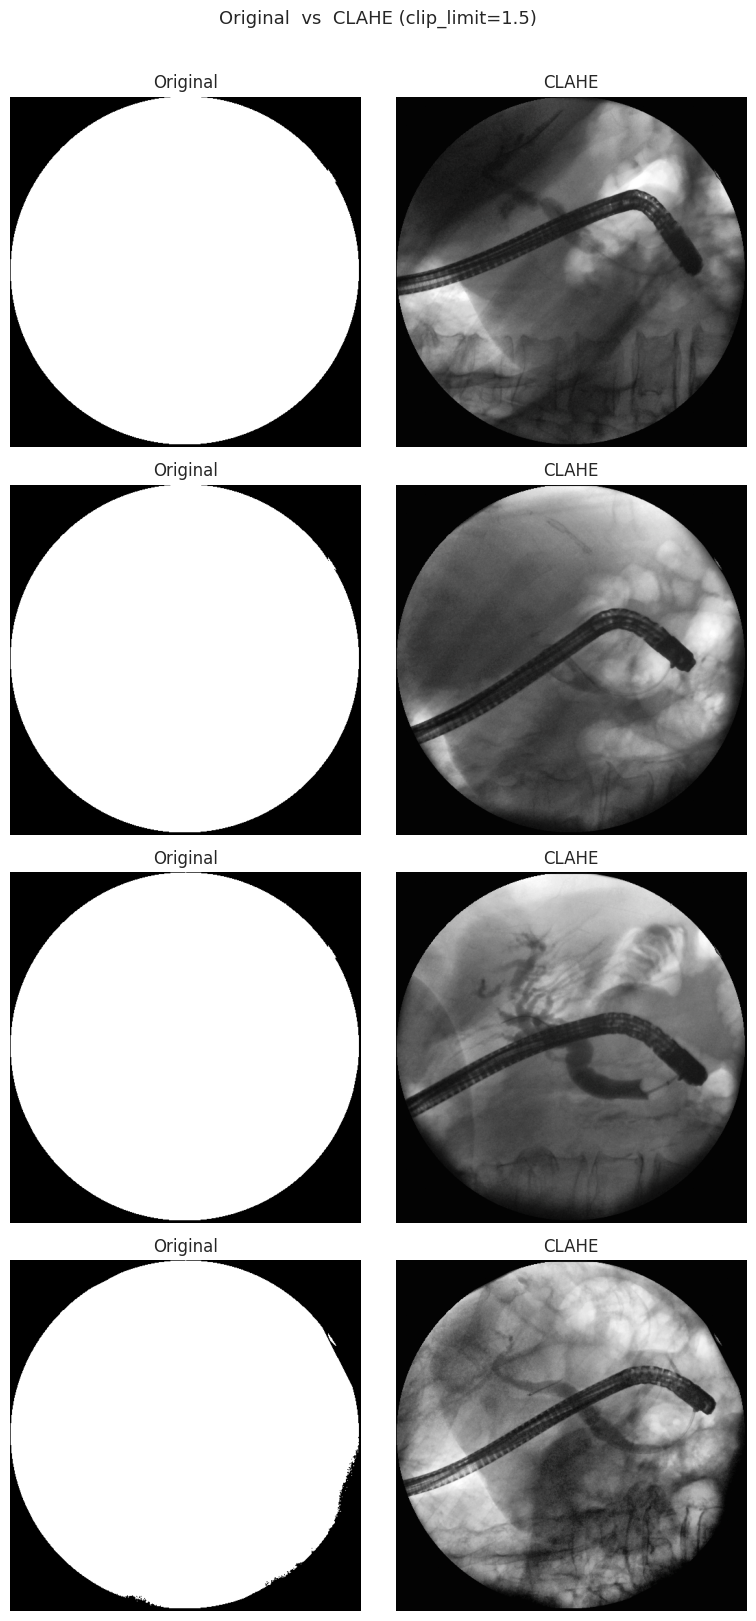

Saved clahe_preview.png


In [51]:
# ── Side-by-side visualisation: original vs CLAHE ────────────────────────
# Preview pipeline: NO NormalizeIntensity — keeps values in [0,1] for display
from monai.transforms import LoadImage, EnsureChannelFirst, Resize, ToTensor, Compose, Lambda

_preview_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    ToTensor(),
    Lambda(repeat_if_needed),
])

n_samples = 4
sample_paths = [
    data['train']['images'][i]
    for i in np.random.choice(len(data['train']['images']), n_samples, replace=False)
]

fig, axes = plt.subplots(n_samples, 2, figsize=(8, 4 * n_samples))
fig.suptitle('Original  vs  CLAHE (clip_limit=1.5)', fontsize=13, y=1.01)

clahe_preview = CLAHETransform(clip_limit=1.5)

for row, path in enumerate(sample_paths):
    img = _preview_transforms(path)           # float32, values in [0, 1]
    img_clahe = clahe_preview(img)

    def to_show(t):
        t = t.numpy().transpose(1, 2, 0).clip(0, 1)
        return t if t.shape[2] == 3 else t[:, :, 0]

    axes[row, 0].imshow(to_show(img),       cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title('Original')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(to_show(img_clahe), cmap='gray', vmin=0, vmax=1)
    axes[row, 1].set_title('CLAHE')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.savefig('clahe_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved clahe_preview.png')


In [52]:
train_labels_np = np.array(data['train']['labels'])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_class),
    y=train_labels_np
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print('Class weights:', class_weights_tensor)

# Per-sample weights for WeightedRandomSampler
sample_weights = [class_weights[label] for label in train_labels_np]
print(f'Sample weights — min: {min(sample_weights):.3f}  max: {max(sample_weights):.3f}')


Class weights: tensor([2.4250, 0.5282, 1.3541, 1.0461])
Sample weights — min: 0.528  max: 2.425


In [53]:
class EnsureSingleChannel:
    def __call__(self, img):
        if img.shape[0] == 3:
            img = img.mean(dim=0, keepdim=True)
        return img

def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

_clahe = CLAHETransform(clip_limit=1.5, tile_grid=(8, 8))

train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    ToTensor(),
    Lambda(repeat_if_needed),
    # ── CLAHE on raw [0,1] pixel values — must come before NormalizeIntensity
    Lambda(_clahe),
    # ── Spatial augmentation ───────────────────────────────────────────
    RandFlip(spatial_axis=0, prob=0.5),
    RandFlip(spatial_axis=1, prob=0.5),
    RandAffine(
        prob=0.5,
        rotate_range=0.3,
        shear_range=0.1,
        translate_range=20,
        padding_mode='border'
    ),
    RandZoom(min_zoom=0.85, max_zoom=1.15, prob=0.5),
    # ── Intensity augmentation ─────────────────────────────────────────
    RandAdjustContrast(prob=0.5, gamma=(0.7, 1.5)),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.02),
    RandGaussianSmooth(prob=0.2),
    # ── Normalise last — after CLAHE and augmentation ──────────────────
    NormalizeIntensity(),
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    ToTensor(),
    Lambda(repeat_if_needed),
    Lambda(_clahe),
    NormalizeIntensity(),
])

act       = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)

print('Transforms defined — CLAHE before NormalizeIntensity.')


Transforms defined — CLAHE before NormalizeIntensity.


In [54]:
from torch.utils.data import WeightedRandomSampler

class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels      = labels
        self.transforms  = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]


train_ds = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms)
val_ds   = MedNISTDataset(data['val']['images'],   data['val']['labels'],   val_transforms)
test_ds  = MedNISTDataset(data['test']['images'],  data['test']['labels'],  val_transforms)

# WeightedRandomSampler — gives minority classes equal expected frequency
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=4, sampler=sampler,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=4, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')


Train batches: 267 | Val batches: 59 | Test batches: 67


In [55]:
device = torch.device("cuda:0")
model = efficientnet_b7(pretrained=True) 
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_class) 
model = model.to(device)

/mounts/mecd-ap-g6/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mounts/mecd-ap-g6/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B7_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B7_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [56]:
def train_model(train_dl, val_dl, model, loss_function, optimizer, epochs, name,
                scheduler=None):
    early_stopping_patience = 10
    epochs_without_improvement = 0
    liveloss = PlotLosses(outputs=[MatplotlibPlot(figpath=f'{name}.png')])
    best_metric = -1
    best_metric_epoch = -1
    best_train_f1 = -1

    f1_metric  = MulticlassF1Score(num_classes=num_class, average='macro').to(device)
    auc_metric = ROCAUCMetric()

    for epoch in range(epochs):
        logs = {}
        model.train()
        running_loss = 0.0
        running_corrects = 0.0
        y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
        y_train      = torch.tensor([], dtype=torch.long,    device=device)

        for inputs, labels in train_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = loss_function(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
                scheduler.step()
            running_loss     += loss.detach() * inputs.size(0)
            _, preds          = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            y_pred_train      = torch.cat([y_pred_train, outputs], dim=0)
            y_train           = torch.cat([y_train, labels],        dim=0)

        epoch_loss = running_loss / len(train_dl.dataset)
        epoch_acc  = running_corrects.float() / len(train_dl.dataset)
        f1_train   = f1_metric(y_pred_train.argmax(dim=1), y_train)
        logs.update({'loss': epoch_loss.item(), 'accuracy': epoch_acc.item(),
                     'F1': f1_train.item()})

        model.eval()
        running_loss = 0.0
        running_corrects = 0.0
        y_pred = torch.tensor([], dtype=torch.float32, device=device)
        y      = torch.tensor([], dtype=torch.long,    device=device)

        with torch.no_grad():
            for val_images, val_labels in val_dl:
                val_images, val_labels = val_images.to(device), val_labels.to(device)
                outputs       = model(val_images)
                loss          = loss_function(outputs, val_labels)
                running_loss += loss.detach() * val_images.size(0)
                _, preds      = torch.max(outputs, 1)
                running_corrects += torch.sum(preds == val_labels.data)
                y_pred = torch.cat([y_pred, outputs], dim=0)
                y      = torch.cat([y, val_labels],   dim=0)

            epoch_loss = running_loss / len(val_dl.dataset)
            epoch_acc  = running_corrects.float() / len(val_dl.dataset)
            f1_val     = f1_metric(y_pred.argmax(dim=1), y)
            logs.update({'val_loss': epoch_loss.item(), 'val_accuracy': epoch_acc.item(),
                         'val_F1': f1_val.item()})

            y_onehot   = [to_onehot(i) for i in decollate_batch(y, detach=False)]
            y_pred_act = [act(i)       for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            logs['val_AUC'] = result

            if f1_val > best_metric:
                best_metric       = f1_val
                best_metric_epoch = epoch + 1
                best_train_f1     = f1_train.item()
                torch.save(model.state_dict(), name)
                print('saved new best metric model')
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= early_stopping_patience:
                print(f'Early stopping at epoch {epoch+1} | '
                      f'Best Val F1: {best_metric:.4f} @ epoch {best_metric_epoch}')
                break

            print(f'ep {epoch+1:3d} | AUC {result:.4f} | '
                  f'F1 tr {f1_train:.4f} | F1 val {f1_val:.4f} | '
                  f'best {best_metric:.4f} @ ep {best_metric_epoch}')

        liveloss.update(logs)
        liveloss.send()

        if scheduler is not None and not isinstance(
            scheduler, torch.optim.lr_scheduler.OneCycleLR
        ):
            scheduler.step()

    print(f'Training done — best F1: {best_metric:.4f} at epoch {best_metric_epoch}')


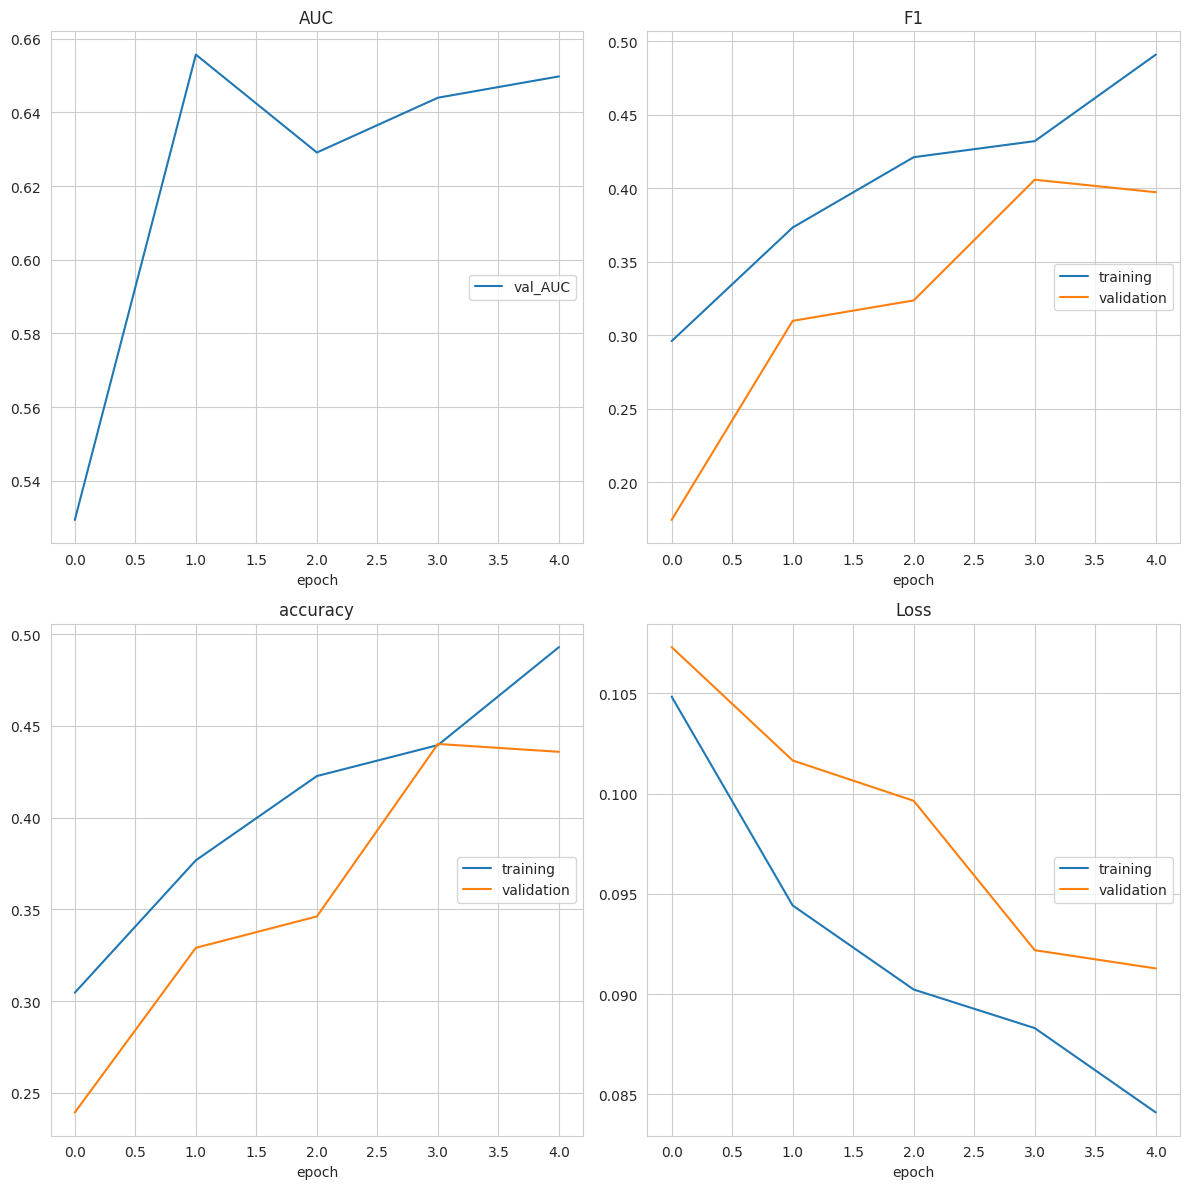

Training done — best F1: 0.4057 at epoch 4
Phase 1 time: 89s


In [57]:
EPOCHS_PHASE1 = 5
EPOCHS_PHASE2 = 55

device = torch.device('cuda:0')

# MONAI FocalLoss expects one-hot labels — wrap it to handle integer class indices
from monai.losses import FocalLoss as MonaiFocalLoss

class FocalLossWrapper(nn.Module):
    """Converts integer labels to one-hot before passing to MONAI FocalLoss."""
    def __init__(self, num_classes, gamma=3.0, weight=None):
        super().__init__()
        self.num_classes = num_classes
        self.focal = MonaiFocalLoss(gamma=gamma, weight=weight, reduction='mean')

    def forward(self, inputs, targets):
        # inputs : (B, C) logits
        # targets: (B,)  integer class indices
        targets_onehot = torch.zeros_like(inputs)  # (B, C)
        targets_onehot.scatter_(1, targets.unsqueeze(1), 1.0)
        return self.focal(inputs, targets_onehot)


loss_function = FocalLossWrapper(
    num_classes=num_class,
    gamma=3.0,
    weight=class_weights_tensor.to(device)
)

# Phase 1: freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

optimizer_p1 = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)
scheduler_p1 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_p1,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS_PHASE1
)

print('=== Phase 1: training classifier head only ===')
starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function,
            optimizer_p1, EPOCHS_PHASE1, model_name, scheduler=scheduler_p1)
print(f'Phase 1 time: {time.perf_counter() - starttime:.0f}s')


In [69]:
for param in model.features.parameters():
    param.requires_grad = True

optimizer_p2 = torch.optim.Adam([
    {'params': model.features.parameters(),    'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-4},
])

scheduler_p2 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_p2,
    max_lr=[1e-5, 1e-4],
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS_PHASE2
)

print('=== Phase 2: full fine-tuning with differential LRs ===')
starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function,
            optimizer_p2, EPOCHS_PHASE2, model_name, scheduler=scheduler_p2)
print(f'Phase 2 time: {time.perf_counter() - starttime:.0f}s')


=== Phase 2: full fine-tuning with differential LRs ===


OutOfMemoryError: CUDA out of memory. Tried to allocate 64.00 MiB. GPU 0 has a total capacity of 47.37 GiB of which 10.12 MiB is free. Process 685 has 7.39 GiB memory in use. Process 1551 has 21.22 GiB memory in use. Process 13289 has 1.85 GiB memory in use. Process 22968 has 1.84 GiB memory in use. Including non-PyTorch memory, this process has 13.14 GiB memory in use. Of the allocated memory 12.15 GiB is allocated by PyTorch, and 431.53 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [67]:
!nvidia-smi

Sun May 24 10:23:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.03             Driver Version: 580.159.03     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 6000 Ada Gene...    Off |   00000000:41:00.0 Off |                  Off |
| 30%   55C    P8             30W /  300W |   48496MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
def evaluate_model(test_dl, model):
    """Standard inference — no augmentation."""
    model.eval()
    predictions, actual_values = [], []
    with torch.no_grad():
        for inputs, labels in test_dl:
            inputs = inputs.to(device)
            yprev  = model(inputs).cpu().numpy()
            actual = labels.numpy()
            predictions.append(np.argmax(yprev, axis=1).reshape(-1, 1))
            actual_values.append(actual.reshape(-1, 1))
    predictions   = np.vstack(predictions)
    actual_values = np.vstack(actual_values)
    f1 = f1_score(actual_values, predictions, average='macro')
    print(f'F1 Score (no TTA): {f1:.4f}')
    return actual_values, predictions


tta_aug = Compose([
    RandFlip(spatial_axis=0, prob=0.5),
    RandFlip(spatial_axis=1, prob=0.5),
    RandAffine(prob=0.5, rotate_range=0.2, translate_range=10, padding_mode='border'),
    RandAdjustContrast(prob=0.3, gamma=(0.8, 1.2)),
])

def evaluate_model_tta(test_dl, model, n_tta=5):
    """Inference with TTA: average softmax over n_tta augmented copies."""
    model.eval()
    predictions, actual_values = [], []
    with torch.no_grad():
        for inputs, labels in test_dl:
            inputs = inputs.to(device)
            probs  = torch.zeros(inputs.size(0), num_class, device=device)
            for _ in range(n_tta):
                aug = torch.stack([tta_aug(img.cpu()).to(device) for img in inputs])
                probs += torch.softmax(model(aug), dim=1)
            probs /= n_tta
            predictions.append(probs.argmax(dim=1).cpu().numpy().reshape(-1, 1))
            actual_values.append(labels.numpy().reshape(-1, 1))
    predictions   = np.vstack(predictions)
    actual_values = np.vstack(actual_values)
    f1 = f1_score(actual_values, predictions, average='macro')
    print(f'F1 Score (TTA x{n_tta}): {f1:.4f}')
    return actual_values, predictions


def display_results(actual_values, predictions):
    acc = accuracy_score(actual_values, predictions)
    f1  = f1_score(actual_values, predictions, average='macro')
    print(f'Accuracy : {acc:.4f}  |  F1 macro: {f1:.4f}')
    print(classification_report(actual_values, predictions,
                                 target_names=class_names, digits=4, zero_division=0))


def display_confusion_matrix(cm, list_classes, filename):
    plt.figure(figsize=(16, 8))
    sns.heatmap(cm, annot=True,
                xticklabels=list_classes, yticklabels=list_classes,
                annot_kws={'size': 12}, fmt='g', linewidths=.5)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig(f'{filename}_cm.png', dpi=300)
    plt.show()


# ── Load best checkpoint ──────────────────────────────────────────────────
model.load_state_dict(torch.load(model_name))
model.eval()

print('\n--- Standard inference ---')
av, pr = evaluate_model(test_loader, model)
display_results(av, pr)

print('\n--- TTA x5 ---')
av_tta, pr_tta = evaluate_model_tta(test_loader, model, n_tta=5)
display_results(av_tta, pr_tta)

cm = confusion_matrix(av_tta, pr_tta)
display_confusion_matrix(cm, class_names, model_name)


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

def get_probs(dl, model):
    """Return softmax probabilities and true labels for a dataloader."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in dl:
            inputs = inputs.to(device)
            probs  = torch.softmax(model(inputs), dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    return np.vstack(all_probs), np.concatenate(all_labels)


def tune_thresholds(val_probs, val_labels, num_classes, n_steps=50):
    """
    For each class independently, sweep the threshold on the validation set
    and pick the value that maximises that class's F1.
    Returns a threshold array of shape (num_classes,).
    """
    thresholds = np.full(num_classes, 1.0 / num_classes)  # default: uniform
    for c in range(num_classes):
        best_t, best_f1 = thresholds[c], 0.0
        for t in np.linspace(0.05, 0.95, n_steps):
            # predict class c whenever its prob > t, else argmax of the rest
            preds = np.where(val_probs[:, c] > t, c,
                             np.argmax(np.delete(val_probs, c, axis=1), axis=1))
            # shift indices back for classes after c
            preds = np.where(preds >= c, preds + (preds >= c), preds)
            f1 = f1_score(val_labels, preds, labels=[c], average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        thresholds[c] = best_t
        print(f'  Class {c:2d} ({class_names[c]:20s}): best threshold = {best_t:.2f}  F1 = {best_f1:.4f}')
    return thresholds


def predict_with_thresholds(probs, thresholds):
    """Apply per-class thresholds; highest-threshold-exceeding class wins, else argmax."""
    preds = np.argmax(probs, axis=1)  # fallback
    for c, t in enumerate(thresholds):
        preds = np.where(probs[:, c] > t, c, preds)
    return preds


# ── Load best checkpoint ──────────────────────────────────────────────────
model.load_state_dict(torch.load(model_name))
model.eval()

print('Getting validation probabilities...')
val_probs, val_labels_arr = get_probs(val_loader, model)

print('\nTuning thresholds on validation set:')
thresholds = tune_thresholds(val_probs, val_labels_arr, num_class)
print('\nFinal thresholds:', thresholds)

# ── Evaluate on test set ──────────────────────────────────────────────────
print('\nGetting test probabilities (with TTA x5)...')

def get_tta_probs(dl, model, n_tta=5):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in dl:
            inputs = inputs.to(device)
            probs  = torch.zeros(inputs.size(0), num_class, device=device)
            for _ in range(n_tta):
                aug = torch.stack([tta_aug(img.cpu()).to(device) for img in inputs])
                probs += torch.softmax(model(aug), dim=1)
            probs /= n_tta
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.vstack(all_probs), np.concatenate(all_labels)

test_probs, test_labels_arr = get_tta_probs(test_loader, model, n_tta=5)

print('\n--- TTA x5 + argmax (no threshold tuning) ---')
preds_base = np.argmax(test_probs, axis=1)
print(f'F1 macro: {f1_score(test_labels_arr, preds_base, average="macro"):.4f}')
print(classification_report(test_labels_arr, preds_base,
                             target_names=class_names, digits=4, zero_division=0))

print('\n--- TTA x5 + threshold tuning ---')
preds_tuned = predict_with_thresholds(test_probs, thresholds)
print(f'F1 macro: {f1_score(test_labels_arr, preds_tuned, average="macro"):.4f}')
print(classification_report(test_labels_arr, preds_tuned,
                             target_names=class_names, digits=4, zero_division=0))

cm = confusion_matrix(test_labels_arr, preds_tuned)
display_confusion_matrix(cm, class_names, model_name)
